In [2]:
import numpy as np
from qutip import *
from itertools import product
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import os
import csv
import re
from matplotlib.gridspec import GridSpec

In [3]:
# The explicit database names for the 3 different runs
db_varying_eta = "optimized_states_varying_eta.csv"
db_common_opt = "optimized_states_common_eta.csv"
db_common_uni = "uniform_state.csv"

In [4]:
def generate_combinations(K, N):
    """
    Generate configurations where the sum of particles in K signal modes
    is less than or equal to N. The reference mode is implicit.
    """
    all_combinations = product(range(N + 1), repeat=K)
    # Corrected logic: sum(comb) <= N
    valid_combinations = [comb for comb in all_combinations if sum(comb) <= N]
    return valid_combinations

In [5]:
def diagonalize(rho):
    """
    Diagonalize the dm rho
    :param rho:
    :return: eigenvalues, eigenvectors
    """
    eigenvalues, eigenvectors = rho.eigenstates()
    return eigenvalues, eigenvectors

In [6]:
def compute_rho_derivative(rho, vals, vecs, generators, a):
    """
    Computes the matrix elements of the derivative ∂_a(ρ) = -1j[n_a, ρ] in the
    eigenbasis of ρ.

    Returns the matrix elements ⟨λ_n | ∂_a(ρ) | λ_m⟩ as a complex numpy array.

    :param rho: Density matrix (QuTiP Qobj)
    :param vals: Array of eigenvalues
    :param vecs: List of eigenvectors (QuTiP kets)
    :param generators: List of number operators
    :param a: Index of the parameter (mode) for the derivative
    :return: (np.ndarray) Matrix elements of the derivative in the eigenbasis
    """
    n_a = generators[a]

    # 1. Construct U, the diagonalizing matrix
    U = Qobj(np.hstack([v.full() for v in vecs]), dims=[rho.dims[0], rho.dims[0]])

    # 2. Transform the generator to the eigenbasis
    n_a_eigen = (U.dag() * n_a * U).full()

    # 3. Create the eigenvalue difference matrix (lambda_m - lambda_n)
    # diffs[n,m] = row[m] - col[n] = lambda_m - lambda_n
    diffs = vals[np.newaxis, :] - vals[:, np.newaxis]

    # 4. Return the result in the eigenbasis (No back-transformation)
    # This matrix contains the elements <n | del_a * rho | m>
    return -1j * diffs * n_a_eigen

In [7]:
def calculate_QFIM(rho, vals, vecs, generators):
    """
    Implements the Quantum Fisher Information Matrix (QFIM) using the spectral
    representation of the Symmetric Logarithmic Derivative (SLD).

    This function corresponds to Formula (11) in Albarelli et al. (2020),
    computing F_ab based on the matrix elements of ρ's derivatives in its
    own eigenbasis.
    https://iopscience.iop.org/article/10.1088/1751-8121/ab5d4d

    :param rho: Density matrix (Qobj)
    :param vals: Pre-calculated eigenvalues of rho
    :param vecs: Pre-calculated eigenvectors of rho
    :param generators: List of number operators for each phase mode
    :return: (np.ndarray) Symmetric KxK QFIM matrix
    """
    dim = len(vals)
    K = len(generators)
    qfim = np.zeros((K, K))


    # Pre-compute all derivative matrices in the eigenbasis
    derivatives_eigen = []
    for a in range(K):
        der_eigen = compute_rho_derivative(rho, vals, vecs, generators, a)
        derivatives_eigen.append(der_eigen)

    # Calculate QFIM elements. QFIM is symmetric, so iteration is on upper "triangle"
    for a in range(K):
        for b in range(a, K):
            term_sum = 0
            # Formula (11) double sum over eigenvalues
            for n in range(dim):
                for m in range(dim):
                    v_sum = vals[n] + vals[m]
                    if v_sum > 1e-14:
                        # Extract <n| del_a_rho |m> and <m| del_b_rho |n>
                        elem_a = derivatives_eigen[a][n, m]
                        elem_b = derivatives_eigen[b][m, n]

                        # Weighting 2 / (lambda_n + lambda_m)
                        term_sum += (2.0 / v_sum) * np.real(elem_a * elem_b)

            qfim[a, b] = term_sum
            qfim[b, a] = term_sum

    return qfim

In [8]:
def N_free(initial_signal_state, eta_vec, N, K):
    """
    Implements the independent noise channel (N_free) via Stinespring dilation.
    Now accepts eta_vec to allow different transmission coefficients per mode.
    """
    D = N + 1

    # 1. Global Unitary Initialization
    V_total = tensor([qeye(D)] * (2 * K))

    # 2. Sequential interaction application
    for i in range(K):
        # Calculate theta for this specific mode's eta
        theta_i = np.arccos(np.sqrt(eta_vec[i]))

        ops_s = [qeye(D)] * (2 * K); ops_s[i] = destroy(D)
        ops_e = [qeye(D)] * (2 * K); ops_e[K + i] = destroy(D)

        a_s = tensor(ops_s)
        a_e = tensor(ops_e)

        h_int = a_s.dag() * a_e - a_s * a_e.dag()
        V_total = (theta_i * h_int).expm() * V_total

    # 3. Initialize joint state
    env_vacuum = tensor([basis(D, 0)] * K)
    rho_joint = ket2dm(tensor(initial_signal_state, env_vacuum))

    rho_final_joint = V_total * rho_joint * V_total.dag()

    return rho_final_joint.ptrace(list(range(K)))

In [9]:
def N_int(initial_signal_state, eta_vec, N, K):
    """
    Implements N_int (Shared Environment).
    Signal: Modes 0 to K-1. Environment: Mode K.
    Total Modes: K + 1.
    Uses a vector of etas
    """
    D = N + 1
    a_e = tensor([qeye(D)] * K + [destroy(D)])

    h_tot = tensor([qeye(D)] * (K + 1)) * 0.0

    for i in range(K):
        # Calculate theta specific to this mode's transmission
        theta_i = np.arccos(np.sqrt(eta_vec[i]))

        ops_s = [qeye(D)] * (K + 1); ops_s[i] = destroy(D)
        a_s = tensor(ops_s)

        h_int_i = a_s.dag() * a_e - a_s * a_e.dag()

        # Add the properly weighted generator to the total Hamiltonian
        h_tot += theta_i * h_int_i

    # Exponentiate the properly summed generators
    V_total = h_tot.expm()

    rho_joint = ket2dm(tensor(initial_signal_state, basis(D, 0)))
    rho_final = V_total * rho_joint * V_total.dag()
    return rho_final.ptrace(list(range(K)))

In [10]:
def N_tot(initial_ket, eta_vec, p, N, K):
    """
    Implements the total noisy channel:
    rho_tot = p * N_free(rho_i) + (1 - p) * N_int(rho_i)

    Now accepts eta_vec to allow different transmission coefficients per mode.
    """
    # 1. Calculate the independent noise component (p probability)
    rho_free = N_free(initial_ket, eta_vec, N, K)

    # 2. Calculate the interacting noise component (1-p probability)
    rho_int = N_int(initial_ket, eta_vec, N, K)

    # 3. Sum the components to get the total mixed state
    rho_tot = p * rho_free + (1.0 - p) * rho_int

    return rho_tot

In [11]:
def optimize_initial_state(N, K, eta_vec, p):
    """
    Optimizes the initial probe state to maximize QFI under noise.
    Now accepts eta_vec for mode-specific losses and returns the total variance.
    """
    D = N + 1
    combinations = generate_combinations(K, N)
    num_coeffs = len(combinations)

    generators = []
    for i in range(K):
        ops = [qeye(D)] * K
        ops[i] = num(D)
        generators.append(tensor(ops))

    basis_kets = []
    for comb in combinations:
        state_modes = [basis(D, n) for n in comb]
        basis_kets.append(tensor(state_modes))

    def objective(coeffs):
        norm = np.linalg.norm(coeffs)
        if norm < 1e-10: return 0.0
        initial_ket = sum((coeffs[i] / norm) * basis_kets[i] for i in range(num_coeffs))

        # Updated to use eta_vec
        rho_out = N_tot(initial_ket, eta_vec, p, N, K)
        vals, vecs = diagonalize(rho_out)
        qfim = calculate_QFIM(rho_out, vals, vecs, generators)
        return -1.0 * np.trace(qfim)

    start_coeffs = np.array([1.0 / np.sqrt(num_coeffs)] * num_coeffs)
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x**2) - 1})
    bnds = [(0, 1) for _ in range(num_coeffs)]
    res = minimize(objective, start_coeffs, method='SLSQP', bounds=bnds, constraints=cons)

    # --- NEW: Evaluate the final metrics for the optimized state ---
    opt_coeffs = res.x
    norm = np.linalg.norm(opt_coeffs)
    initial_ket = sum((opt_coeffs[i] / norm) * basis_kets[i] for i in range(num_coeffs))

    rho_out = N_tot(initial_ket, eta_vec, p, N, K)
    vals, vecs = diagonalize(rho_out)
    qfim = calculate_QFIM(rho_out, vals, vecs, generators)

    max_qfi = np.trace(qfim)
    try:
        # Cramér-Rao Bound (Total Variance) is the trace of the inverse QFIM
        total_var = np.trace(np.linalg.pinv(qfim))
    except:
        total_var = np.inf

    return res.x, combinations, max_qfi, total_var

In [12]:
def format_ket_latex(coeffs, combinations, threshold=1e-2):
    """
    Helper to format kets using LaTeX notation with 2-digit precision.
    """
    terms = []
    for c, comb in zip(coeffs, combinations):
        if np.abs(c) > threshold:
            basis_str = f"|{','.join(map(str, comb))}\\rangle"
            terms.append(f"{c:.2f}{basis_str}")
    final_str = " + ".join(terms) if terms else "0"
    return f"${final_str}$"

In [13]:
def evaluate_uniform_state(N, K, eta_vec, p):
    """Evaluates the non-optimized uniform superposition state."""
    D = N + 1
    combinations = generate_combinations(K, N)
    num_coeffs = len(combinations)

    generators = []
    for i in range(K):
        ops = [qeye(D)] * K
        ops[i] = num(D)
        generators.append(tensor(ops))

    basis_kets = []
    for comb in combinations:
        state_modes = [basis(D, n) for n in comb]
        basis_kets.append(tensor(state_modes))

    coeffs = np.array([1.0 / np.sqrt(num_coeffs)] * num_coeffs)
    norm = np.linalg.norm(coeffs)
    initial_ket = sum((coeffs[i] / norm) * basis_kets[i] for i in range(num_coeffs))

    rho_out = N_tot(initial_ket, eta_vec, p, N, K)
    vals, vecs = diagonalize(rho_out)
    qfim = calculate_QFIM(rho_out, vals, vecs, generators)

    qfi = np.trace(qfim)
    try:
        total_var = np.trace(np.linalg.pinv(qfim))
    except:
        total_var = np.inf

    return coeffs, combinations, qfi, total_var

In [14]:
def reorganize_database_to_excel(input_file="optimized_states_database.csv", output_file="tidy_optimized_states.xlsx"):
    """
    Transforms the raw CSV into a formatted Excel table.
    Fock combinations are columns, coefficients are rounded to 6 decimal places.
    Updated for vector eta, total variance, and uniform state tracking.
    """
    if not os.path.exists(input_file):
        print(f"Error: '{input_file}' not found.")
        return

    # 1. Load and Parse
    df = pd.read_csv(input_file)
    tidy_data = []
    unique_combinations = set()

    for _, row in df.iterrows():
        entry = {
            'N': int(row['N']),
            'K': int(row['K']),
            'eta_vec': str(row['eta_vec']),  # Kept as string since it's a list
            'p': round(float(row['p']), 4),
            'max_qfi': round(float(row['max_qfi']), 6),
            'total_variance': round(float(row['total_variance']), 6) if not pd.isna(row['total_variance']) else 'inf',
            'is_uniform': bool(row['is_uniform'])
        }

        coeffs = [float(x) for x in str(row['coeffs']).split(',')]
        combs = [f"|{c}>" for c in str(row['combinations']).split(';')]

        for c, val in zip(combs, coeffs):
            entry[c] = round(val, 6)
            unique_combinations.add(c)
        tidy_data.append(entry)

    # 2. Structure DataFrame
    tidy_df = pd.DataFrame(tidy_data)
    metadata_cols = ['N', 'K', 'eta_vec', 'p', 'max_qfi', 'total_variance', 'is_uniform']
    basis_cols = sorted(list(unique_combinations))
    tidy_df = tidy_df.reindex(columns=metadata_cols + basis_cols).fillna(0.0)

    # 3. Save as Formatted Excel
    with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
        tidy_df.to_excel(writer, index=False, sheet_name='Optimized Coefficients')

        workbook  = writer.book
        worksheet = writer.sheets['Optimized Coefficients']

        # Formatting: Freeze the first row and metadata columns (up to column 7)
        worksheet.freeze_panes(1, 7)

        # Apply a simple table style and adjust column widths
        header_format = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1})
        for col_num, value in enumerate(tidy_df.columns.values):
            worksheet.write(0, col_num, value, header_format)
            column_len = max(len(str(value)), 10)
            worksheet.set_column(col_num, col_num, column_len)

    print(f"--- Tidied Excel database saved as '{output_file}' ---")
    return tidy_df

# Execute
# tidy_db = reorganize_database_to_excel()

--- PASS 1: Scanning for Maximum Figure Dimensions ---

--- PASS 2: Generating Final Uncropped Plots ---
Plotting Varying Eta [0.5, 0.5]...
  -> Saved perfectly sized figure to plots_output/varying_eta_0.5_0.5_custom_axi.png


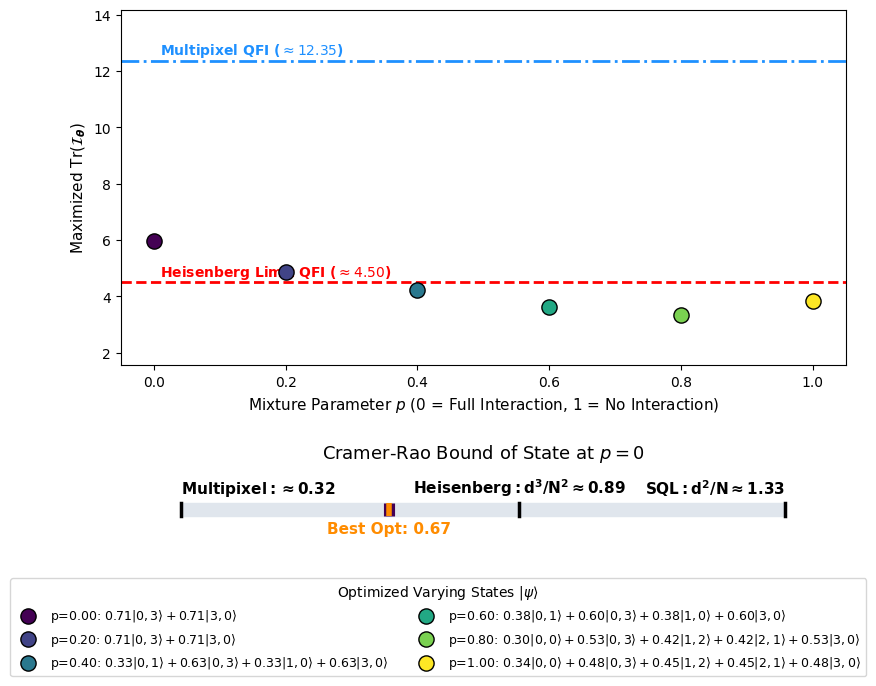

Plotting Varying Eta [1.0, 0.5]...
  -> Saved perfectly sized figure to plots_output/varying_eta_1.0_0.5_custom_axi.png


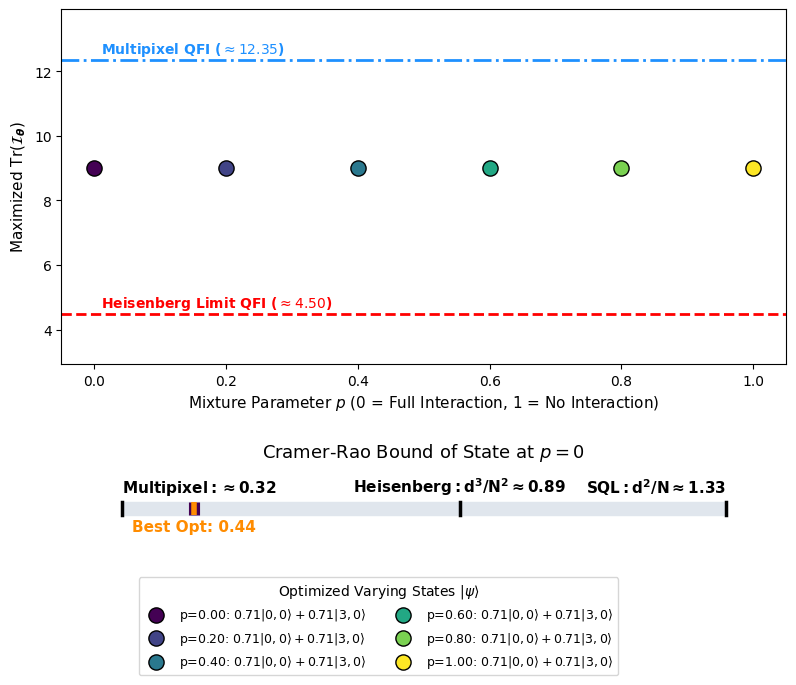

Plotting Uniform State for Eta 0.3...
  -> Saved perfectly sized figure to plots_output/common_uni_eta_0.3_custom_axi.png


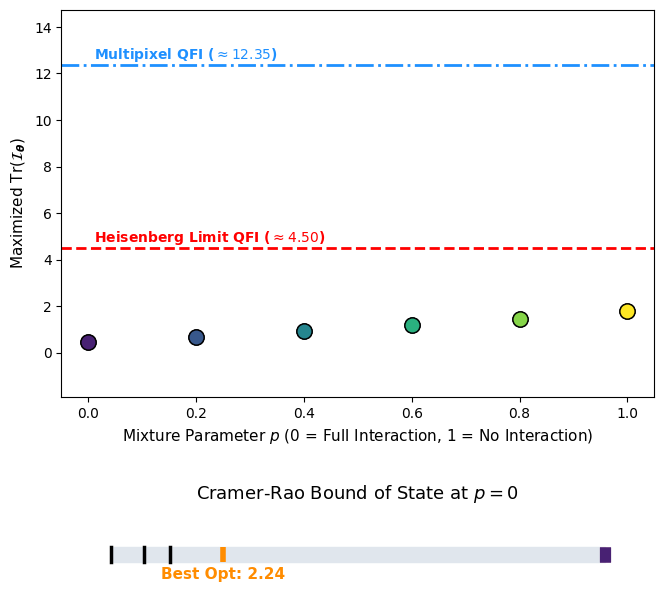

Plotting Uniform State for Eta 0.8...
  -> Saved perfectly sized figure to plots_output/common_uni_eta_0.8_custom_axi.png


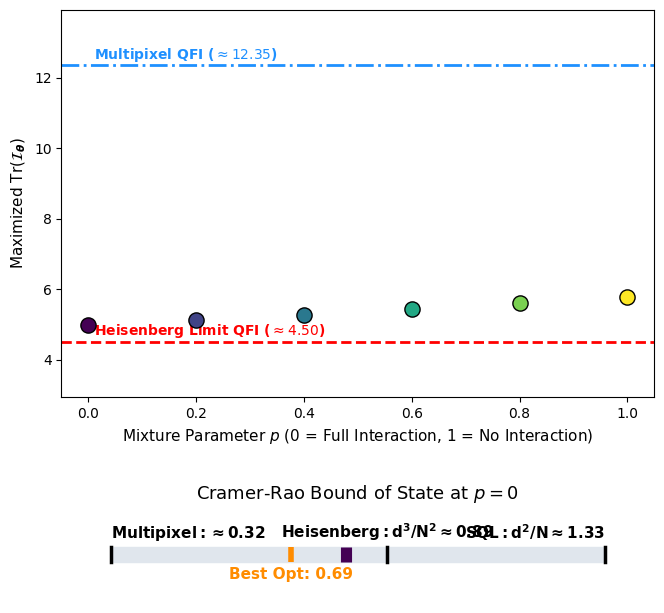

Plotting Common Eta 0.1 (Optimized)...
  -> Saved perfectly sized figure to plots_output/common_opt_eta_0.1_custom_axi.png


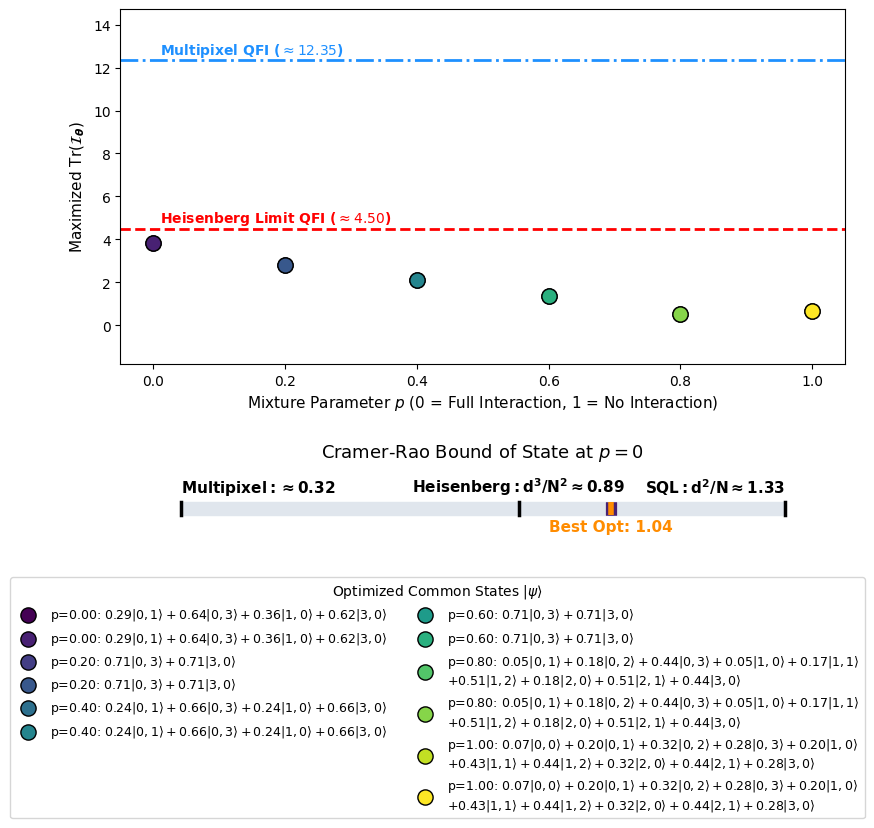

Plotting Common Eta 0.3 (Optimized)...
  -> Saved perfectly sized figure to plots_output/common_opt_eta_0.3_custom_axi.png


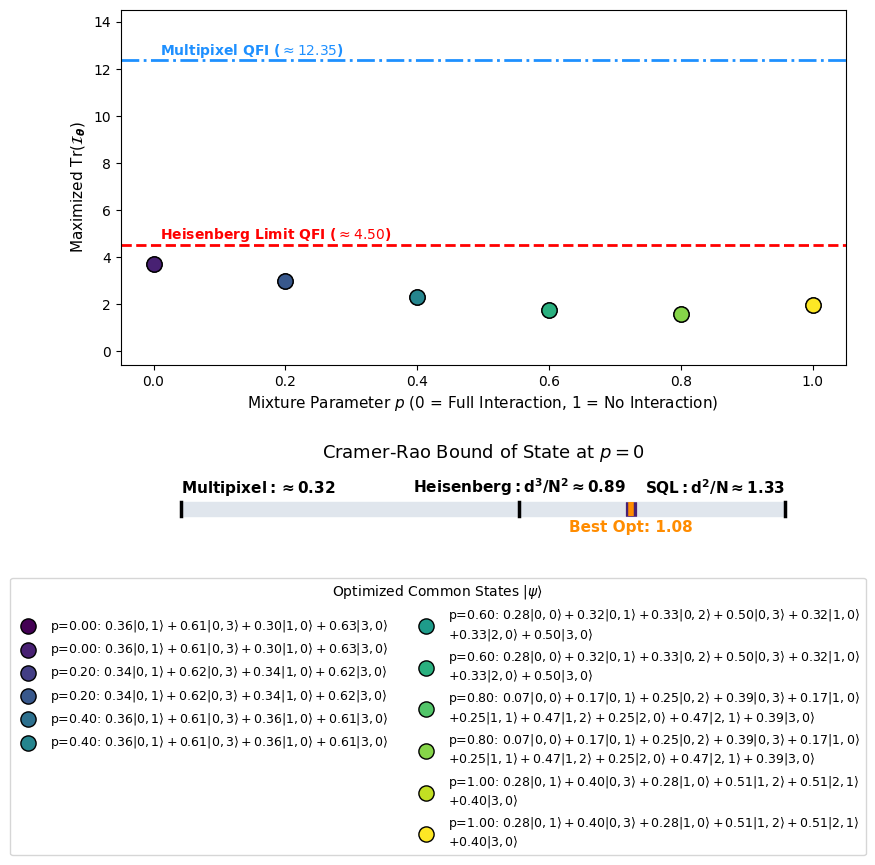

Plotting Common Eta 0.6 (Optimized)...
  -> Saved perfectly sized figure to plots_output/common_opt_eta_0.6_custom_axi.png


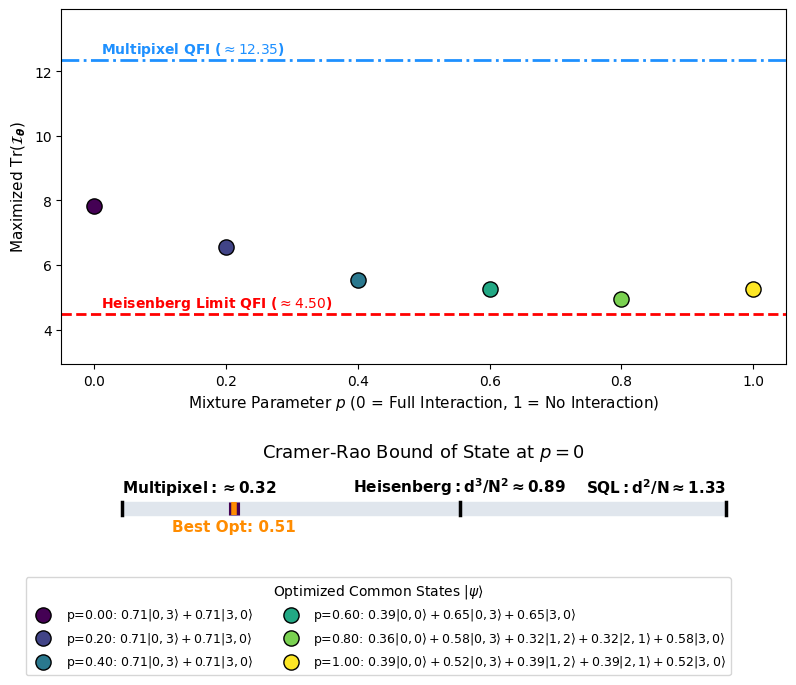

Plotting Common Eta 0.8 (Optimized)...
  -> Saved perfectly sized figure to plots_output/common_opt_eta_0.8_custom_axi.png


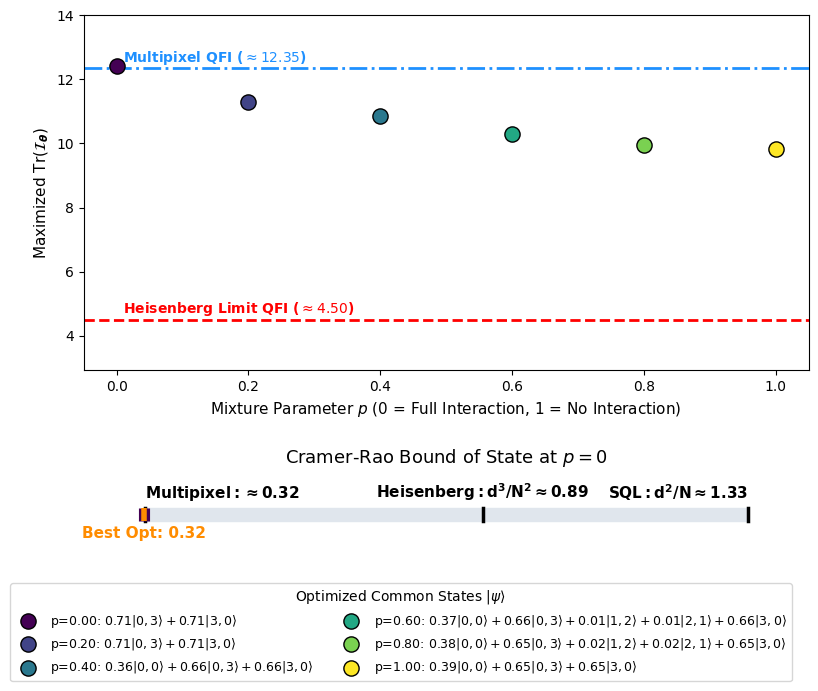


Finished generating split-logic 1D plots with min/max CRB bounds!


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
from matplotlib.gridspec import GridSpec

def format_ket_latex(coeffs, combinations, threshold=1e-2):
    terms = []
    for c, comb in zip(coeffs, combinations):
        if np.abs(c) > threshold:
            basis_str = f"|{','.join(map(str, comb))}\\rangle"
            terms.append(f"{c:.2f}{basis_str}")

    if not terms: return "$0$"
    chunks = [terms[i:i + 5] for i in range(0, len(terms), 5)]
    lines = []
    for i, chunk in enumerate(chunks):
        if i == 0: lines.append(f"${' + '.join(chunk)}$")
        else: lines.append(f"$+ {' + '.join(chunk)}$")
    return "\n".join(lines)

def plot_from_database(N_target, K_target, eta_vec_target, filename, title_prefix="Optimized", save_path=None, forced_size=None, hide_legend=False, hide_benchmark_labels=False):
    if not os.path.exists(filename):
        return None

    plt.rcParams.update({
        'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
        'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
        'ytick.color': 'black', 'axes.edgecolor': 'black'
    })

    df = pd.read_csv(filename)
    target_scalar = float(eta_vec_target[0])

    def is_eta_match(s):
        clean_s = str(s).replace('np.float64(', '').replace(')', '')
        vals = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", clean_s)
        if not vals: return False
        return np.isclose(float(vals[0]), target_scalar, atol=1e-3)

    p_targets = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    mask = (df['N'] == N_target) & (df['K'] == K_target) & \
           (df['eta_vec'].apply(is_eta_match)) & \
           (df['p'].apply(lambda x: any(np.isclose(x, pt, atol=0.01) for pt in p_targets)))

    subset = df[mask].sort_values(by='p')
    if subset.empty: return None

    current_size = forced_size if forced_size else 8.0
    fig = plt.figure(figsize=(current_size, current_size))
    fig.patch.set_facecolor('white')
    fig.patch.set_alpha(1.0)
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.45)

    ax_qfi = fig.add_subplot(gs[0])
    ax_var = fig.add_subplot(gs[1])

    d, N = K_target, N_target
    sql_val = (d**2) / N
    noon_val = (d**3) / (N**2)
    optimal_hl_val = (d * (1 + np.sqrt(d))**2) / (4 * (N**2))

    # --- CALCULATE EXACT BOUNDS (LHS and RHS) ---
    computed_bound = sql_val # Safe fallback
    for _, row in subset.iterrows():
        if np.isclose(row['p'], 0.0, atol=0.01) and row['max_qfi'] > 0:
            computed_bound = (d**2) / row['max_qfi']
            break

    # Calculate Best Optimized State CRB
    best_qfi = subset['max_qfi'].max()
    best_crb = (d**2) / best_qfi

    lhs_bound = min(optimal_hl_val, computed_bound, best_crb)
    rhs_bound = max(sql_val, computed_bound, best_crb)

    margin = (rhs_bound - lhs_bound) * 0.1
    if margin == 0: margin = 0.1
    ax_var.set_xlim(lhs_bound - margin, rhs_bound + margin)
    ax_var.set_ylim(-1.0, 1.0)

    bar_height = 0.15
    ax_var.fill_between([lhs_bound, rhs_bound], -bar_height, bar_height, color='#E0E6ED', zorder=1)

    # --- MODIFIED: DECIMAL LABELS INSTEAD OF FRACTIONS ---
    benchmarks = [optimal_hl_val, noon_val, sql_val]
    benchmark_labels = [
        rf"$\mathbf{{Multipixel: \approx {optimal_hl_val:.2f}}}$",
        rf"$\mathbf{{Heisenberg: d^3/N^2 \approx {noon_val:.2f}}}$",
        rf"$\mathbf{{SQL: d^2/N \approx {sql_val:.2f}}}$"
    ]

    colors = plt.cm.viridis(np.linspace(0, 1, len(subset)))
    qfis = subset['max_qfi'].values

    # --- DRAW THE BENCHMARKS ---
    for i, (val, label) in enumerate(zip(benchmarks, benchmark_labels)):
        ax_var.plot([val, val], [-bar_height, bar_height], color='black', linewidth=2.5, zorder=2)

        if not hide_benchmark_labels:
            if i == 0: ax_var.text(val, bar_height + 0.1, label, color='black', fontsize=11, ha='left', va='bottom')
            elif i == 2: ax_var.text(val, bar_height + 0.1, label, color='black', fontsize=11, ha='right', va='bottom')
            else: ax_var.text(val, bar_height + 0.1, label, color='black', fontsize=11, ha='center', va='bottom')

    # --- PLOT THE DATA ---
    for i, (idx, row) in enumerate(subset.iterrows()):
        p_val = row['p']
        qfi_val = row['max_qfi']
        var_val = (d**2) / qfi_val

        coeffs = [float(x) for x in str(row['coeffs']).split(',')]
        combs = [tuple(map(int, c.split(','))) for c in str(row['combinations']).split(';')]

        latex_ket = format_ket_latex(coeffs, combs)
        legend_label = f"p={p_val:.2f}: {latex_ket}"

        ax_qfi.scatter(p_val, qfi_val, label=legend_label, s=120, color=colors[i], edgecolors='black', zorder=5)

        if np.isclose(p_val, 0.0, atol=0.01):
            ax_var.plot([var_val, var_val], [-bar_height, bar_height], color=colors[i], linewidth=8, solid_capstyle='butt', zorder=5)

    # --- MODIFIED: HIGHLIGHT BEST OPTIMIZED CRB ---
    ax_var.plot([best_crb, best_crb], [-bar_height, bar_height], color='darkorange', linewidth=4, linestyle='--', zorder=6)
    ax_var.text(best_crb, -bar_height - 0.1, rf"Best Opt: {best_crb:.2f}", color='darkorange', fontsize=11, ha='center', va='top', weight='bold')

    # --- MODIFIED: ADD HEISENBERG & MULTIPIXEL LIMIT QFI LINES ---
    hl_qfi_val = (d**2) / noon_val
    multipixel_qfi_val = (d**2) / optimal_hl_val

    ax_qfi.axhline(y=hl_qfi_val, color='red', linestyle='--', linewidth=2, zorder=2)
    ax_qfi.text(0.01, hl_qfi_val + 0.05, rf"Heisenberg Limit QFI ($\approx {hl_qfi_val:.2f}$)",
                color='red', fontsize=10, ha='left', va='bottom', weight='bold')

    ax_qfi.axhline(y=multipixel_qfi_val, color='dodgerblue', linestyle='-.', linewidth=2, zorder=2)
    ax_qfi.text(0.01, multipixel_qfi_val + 0.05, rf"Multipixel QFI ($\approx {multipixel_qfi_val:.2f}$)",
                color='dodgerblue', fontsize=10, ha='left', va='bottom', weight='bold')

    # Ensure all lines are inside the y-axis limits
    all_qfi_values = list(qfis) + [hl_qfi_val, multipixel_qfi_val]
    if len(all_qfi_values) > 0:
        q_min, q_max = np.min(all_qfi_values), np.max(all_qfi_values)
        if q_max == q_min: q_min -= 1; q_max += 1
        ax_qfi.set_ylim(q_min - 0.2*(q_max-q_min), q_max + 0.2*(q_max-q_min))

    ax_qfi.set_xlabel(r"Mixture Parameter $p$ (0 = Full Interaction, 1 = No Interaction)", fontsize=11)
    ax_qfi.set_ylabel(r"Maximized $\mathrm{Tr}(\mathcal{I}_{\boldsymbol{\theta}})$", fontsize=11)
    ax_qfi.grid(True, linestyle=':', alpha=0.4)

    ax_var.set_yticks([]); ax_var.spines['left'].set_visible(False)
    ax_var.spines['right'].set_visible(False); ax_var.spines['top'].set_visible(False)
    ax_var.spines['bottom'].set_visible(False); ax_var.set_xticks([])
    ax_var.set_title(r"Cramer-Rao Bound of State at $p=0$", fontsize=13, pad=5)

    if not hide_legend:
        handles, labels = ax_qfi.get_legend_handles_labels()
        plt.subplots_adjust(left=0.15, bottom=0.35, right=0.95, top=0.95)
        fig.legend(handles, labels, title=rf"{title_prefix} States $|\psi\rangle$",
                   loc='upper center', bbox_to_anchor=(0.5, 0.33),
                   fontsize=9, frameon=True, facecolor='white', ncol=2, title_fontsize='10')
    else:
        plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.95)

    if forced_size is None:
        fig.canvas.draw()
        bbox = fig.get_tightbbox(fig.canvas.get_renderer())
        plt.close(fig)
        return bbox.width, bbox.height
    else:
        if save_path:
            plt.savefig(save_path, dpi=300, facecolor='white', transparent=False)
            print(f"  -> Saved perfectly sized figure to {save_path}")
        plt.show()
        return None

# ==========================================================
# 2-PASS PLOTTING EXECUTION
# ==========================================================
db_varying_eta = "optimized_states_varying_eta.csv"
db_common_opt = "optimized_states_common_eta.csv"
db_common_uni = "uniform_state.csv"
output_dir = "plots_output"
os.makedirs(output_dir, exist_ok=True)

print("--- PASS 1: Scanning for Maximum Figure Dimensions ---")
dim_opt = []
dim_uni = []

varying_etas_to_run = [[0.5, 0.5], [1.0, 0.5]]

for eta_vec_var in varying_etas_to_run:
    res = plot_from_database(N_target=3, K_target=2, eta_vec_target=eta_vec_var, filename=db_varying_eta)
    if res: dim_opt.append(res)

for e in [0.1, 0.3, 0.6, 0.8]:
    res = plot_from_database(N_target=3, K_target=2, eta_vec_target=[e, e], filename=db_common_opt)
    if res: dim_opt.append(res)

for e in [0.3, 0.8]:
    hide_bench = (e == 0.3)
    res = plot_from_database(N_target=3, K_target=2, eta_vec_target=[e, e], filename=db_common_uni, hide_legend=True, hide_benchmark_labels=hide_bench)
    if res: dim_uni.append(res)

g_size_opt = max(max([d[0] for d in dim_opt]), max([d[1] for d in dim_opt])) + 0.5 if dim_opt else 9.0
g_size_uni = max(max([d[0] for d in dim_uni]), max([d[1] for d in dim_uni])) + 0.5 if dim_uni else 8.0

print("\n--- PASS 2: Generating Final Uncropped Plots ---")

for eta_vec_var in varying_etas_to_run:
    print(f"Plotting Varying Eta {eta_vec_var}...")
    plot_from_database(N_target=3, K_target=2, eta_vec_target=eta_vec_var, filename=db_varying_eta,
                       title_prefix="Optimized Varying",
                       save_path=f"{output_dir}/varying_eta_{eta_vec_var[0]}_{eta_vec_var[1]}_custom_axi.png",
                       forced_size=g_size_opt)

for e in [0.3, 0.8]:
    print(f"Plotting Uniform State for Eta {e}...")
    hide_bench = (e == 0.3)
    plot_from_database(N_target=3, K_target=2, eta_vec_target=[e, e], filename=db_common_uni,
                       title_prefix="Uniform",
                       save_path=f"{output_dir}/common_uni_eta_{e}_custom_axi.png",
                       forced_size=g_size_uni, hide_legend=True, hide_benchmark_labels=hide_bench)

for e in [0.1, 0.3, 0.6, 0.8]:
    print(f"Plotting Common Eta {e} (Optimized)...")
    plot_from_database(N_target=3, K_target=2, eta_vec_target=[e, e], filename=db_common_opt,
                       title_prefix="Optimized Common",
                       save_path=f"{output_dir}/common_opt_eta_{e}_custom_axi.png",
                       forced_size=g_size_opt)

print("\nFinished generating split-logic 1D plots with min/max CRB bounds!")

In [16]:
import numpy as np
import csv
import os
import pandas as pd

N_param, K_param = 3, 2
db_varying_eta = "optimized_states_varying_eta.csv"
db_common_opt = "optimized_states_common_eta.csv"
db_common_uni = "uniform_state.csv"

def setup_csv_if_needed(filename):
    if not os.path.isfile(filename):
        with open(filename, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['N', 'K', 'eta_vec', 'p', 'max_qfi', 'total_variance', 'coeffs', 'combinations'])

def get_completed_runs(filename):
    if not os.path.isfile(filename):
        return []
    df = pd.read_csv(filename)
    return list(zip(df['eta_vec'].astype(str), df['p']))

def is_computed(completed_list, eta_vec, p_target, tol=0.01):
    # FIX: Convert the target vector to pure Python floats before turning into a string!
    clean_target = str([float(e) for e in eta_vec])

    for ext_str, p_val in completed_list:
        clean_ext = ext_str.replace('np.float64(', '').replace(')', '')
        if clean_ext == clean_target and abs(float(p_val) - p_target) <= tol:
            return True
    return False

setup_csv_if_needed(db_varying_eta)
setup_csv_if_needed(db_common_opt)
setup_csv_if_needed(db_common_uni)

# ==========================================================
# RUN 1: Varying Eta Loop
# ==========================================================
varying_etas_to_run = [[0.5, 0.5], [1.0, 0.5]]
p_targets_var = [round(x, 1) for x in np.linspace(0.0, 1.0, 11)]
completed_var = get_completed_runs(db_varying_eta)

with open(db_varying_eta, mode='a', newline='') as f:
    writer = csv.writer(f)
    for eta_vec_var in varying_etas_to_run:
        print(f"\n--- Starting RUN 1: Varying Eta {eta_vec_var} ---")
        for p in p_targets_var:
            if is_computed(completed_var, eta_vec_var, p):
                print(f"  Skipping p = {p:.2f} (Already computed)")
                continue

            print(f"  Optimizing for p = {p:.2f}...")
            opt_coeffs, combs, max_qfi, opt_var = optimize_initial_state(N_param, K_param, eta_vec_var, p)
            writer.writerow([N_param, K_param, str(eta_vec_var), p, max_qfi, opt_var,
                             ",".join(map(str, opt_coeffs)),
                             ";".join([",".join(map(str, c)) for c in combs])])

# ==========================================================
# RUN 2 & 3: Common Eta Grid
# ==========================================================
print("\n--- Starting RUNS 2 & 3: Common Eta Grid (0.1 to 1.0) ---")
grid_values = [round(x, 1) for x in np.linspace(0.1, 1.0, 10)]
p_grid_values = [round(x, 1) for x in np.linspace(0.0, 1.0, 11)]

completed_opt = get_completed_runs(db_common_opt)
completed_uni = get_completed_runs(db_common_uni)

with open(db_common_opt, mode='a', newline='') as f_opt, \
     open(db_common_uni, mode='a', newline='') as f_uni:

    writer_opt = csv.writer(f_opt)
    writer_uni = csv.writer(f_uni)

    for eta_val in grid_values:
        # Convert np.float64 explicitly to standard float to avoid string issues
        current_eta_vec = [float(eta_val), float(eta_val)]
        print(f"\n> Sweeping common eta = {eta_val}")

        for p_val in p_grid_values:
            # Check and Run 2: Optimized State
            if is_computed(completed_opt, current_eta_vec, p_val):
                 print(f"    Skipping Optimized p = {p_val:.2f} (Already computed)")
            else:
                 print(f"    Optimizing p = {p_val:.2f}...")
                 opt_coeffs, combs, max_qfi, opt_var = optimize_initial_state(N_param, K_param, current_eta_vec, p_val)
                 writer_opt.writerow([N_param, K_param, str(current_eta_vec), p_val, max_qfi, opt_var,
                                      ",".join(map(str, opt_coeffs)),
                                      ";".join([",".join(map(str, c)) for c in combs])])

            # Check and Run 3: Uniform State
            if is_computed(completed_uni, current_eta_vec, p_val):
                 print(f"    Skipping Uniform p = {p_val:.2f} (Already computed)")
            else:
                 print(f"    Evaluating Uniform p = {p_val:.2f}...")
                 uni_coeffs, _, uni_qfi, uni_var = evaluate_uniform_state(N_param, K_param, current_eta_vec, p_val)
                 writer_uni.writerow([N_param, K_param, str(current_eta_vec), p_val, uni_qfi, uni_var,
                                      ",".join(map(str, uni_coeffs)),
                                      ";".join([",".join(map(str, c)) for c in combs])])

print("\n--- All experiments complete and appended to the databases! ---")


--- Starting RUN 1: Varying Eta [0.5, 0.5] ---
  Skipping p = 0.00 (Already computed)
  Skipping p = 0.10 (Already computed)
  Skipping p = 0.20 (Already computed)
  Skipping p = 0.30 (Already computed)
  Skipping p = 0.40 (Already computed)
  Skipping p = 0.50 (Already computed)
  Skipping p = 0.60 (Already computed)
  Skipping p = 0.70 (Already computed)
  Skipping p = 0.80 (Already computed)
  Skipping p = 0.90 (Already computed)
  Skipping p = 1.00 (Already computed)

--- Starting RUN 1: Varying Eta [1.0, 0.5] ---
  Skipping p = 0.00 (Already computed)
  Skipping p = 0.10 (Already computed)
  Skipping p = 0.20 (Already computed)
  Skipping p = 0.30 (Already computed)
  Skipping p = 0.40 (Already computed)
  Skipping p = 0.50 (Already computed)
  Skipping p = 0.60 (Already computed)
  Skipping p = 0.70 (Already computed)
  Skipping p = 0.80 (Already computed)
  Skipping p = 0.90 (Already computed)
  Skipping p = 1.00 (Already computed)

--- Starting RUNS 2 & 3: Common Eta Grid (0.1


Saved histogram to plots_output/histogram_eta_0.6_p_0.8.png


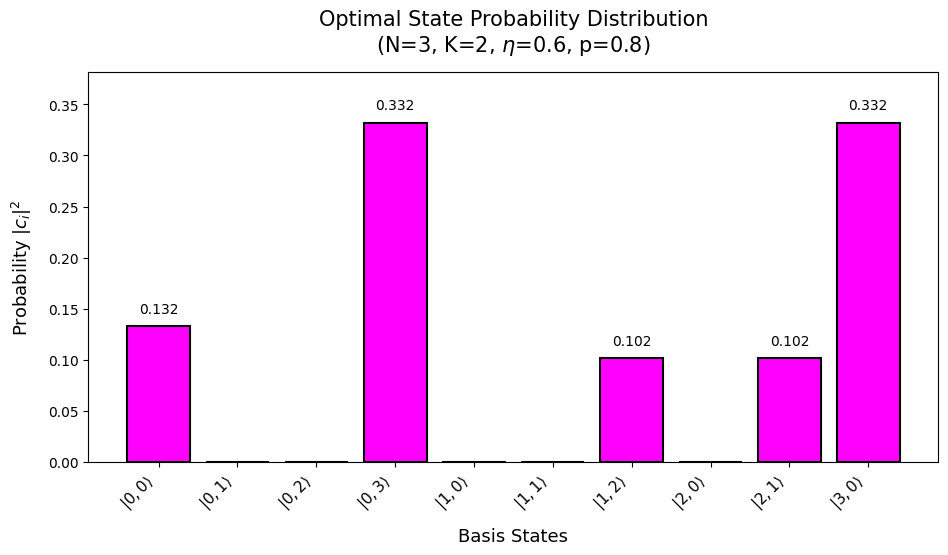

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import os

def plot_optimal_state_histogram(N_target=3, K_target=2, eta_vec_target=[0.6, 0.6], p_target=0.8, filename="optimized_states_common_eta.csv"):

    # FORCE PYCHARM MATPLOTLIB SETTINGS TO WHITE
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.edgecolor': 'black'
    })

    if not os.path.exists(filename):
        print(f"Database file '{filename}' not found.")
        return

    df = pd.read_csv(filename)

    # Robust matching (same as the 1D plots)
    target_scalar = float(eta_vec_target[0])
    def is_eta_match(s):
        clean_s = str(s).replace('np.float64(', '').replace(')', '')
        vals = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", clean_s)
        if not vals: return False
        return np.isclose(float(vals[0]), target_scalar, atol=1e-3)

    mask = (df['N'] == N_target) & \
           (df['K'] == K_target) & \
           (df['eta_vec'].apply(is_eta_match)) & \
           (df['p'].apply(lambda x: np.isclose(float(x), p_target, atol=0.01)))

    subset = df[mask]

    if subset.empty:
        print(f"State for N={N_target}, K={K_target}, eta={eta_vec_target}, p={p_target} not found in database!")
        return

    # Extract coefficients and compute probability
    row = subset.iloc[0]
    coeffs = [float(x) for x in str(row['coeffs']).split(',')]
    combs = [tuple(map(int, c.split(','))) for c in str(row['combinations']).split(';')]

    probs = [c**2 for c in coeffs]
    labels = [f"$|{','.join(map(str, comb))}\\rangle$" for comb in combs]

    # Create the Plot (10x6 ratio to give the 10 labels room to breathe)
    fig = plt.figure(figsize=(10, 6))
    fig.patch.set_facecolor('white')
    fig.patch.set_alpha(1.0)

    ax = fig.add_subplot(111)

    # Magenta bars with a clean black edge
    bars = ax.bar(labels, probs, color='magenta', edgecolor='black', linewidth=1.5, zorder=3)

    # Formatting
    ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
    ax.set_xlabel("Basis States", fontsize=13, labelpad=10)
    ax.set_ylabel(r"Probability $|c_i|^2$", fontsize=13, labelpad=10)

    eta_str = eta_vec_target[0] if eta_vec_target[0] == eta_vec_target[1] else str(eta_vec_target)
    ax.set_title(f"Optimal State Probability Distribution\n(N={N_target}, K={K_target}, $\\eta$={eta_str}, p={p_target})", fontsize=15, pad=15)

    ax.set_ylim(0, max(probs) * 1.15) # Add a little headroom above the tallest bar

    # Add exact values on top of the bars
    for bar in bars:
        height = bar.get_height()
        if height > 0.005: # Only label visible bars (ignores exact 0s)
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # Rotate labels so they don't overlap
    plt.xticks(rotation=45, ha='right', fontsize=11)

    # Fixed margins so the saved file size is consistent
    plt.subplots_adjust(bottom=0.2, top=0.85, left=0.1, right=0.95)

    os.makedirs("plots_output", exist_ok=True)
    save_path = f"plots_output/histogram_eta_{eta_str}_p_{p_target}.png"

    # Fixed size saving (removed bbox_inches='tight')
    plt.savefig(save_path, dpi=300, facecolor='white')
    print(f"\nSaved histogram to {save_path}")

    plt.show()

# ==========================================================
# EXECUTION COMMAND
# ==========================================================
plot_optimal_state_histogram(
    N_target=3,
    K_target=2,
    eta_vec_target=[0.6, 0.6],
    p_target=0.8,
    filename="optimized_states_common_eta.csv"
)

Plotting the full 2D Fidelity Heatmap...
  -> Saved heatmap to plots_output/heatmap_phase_transition.png


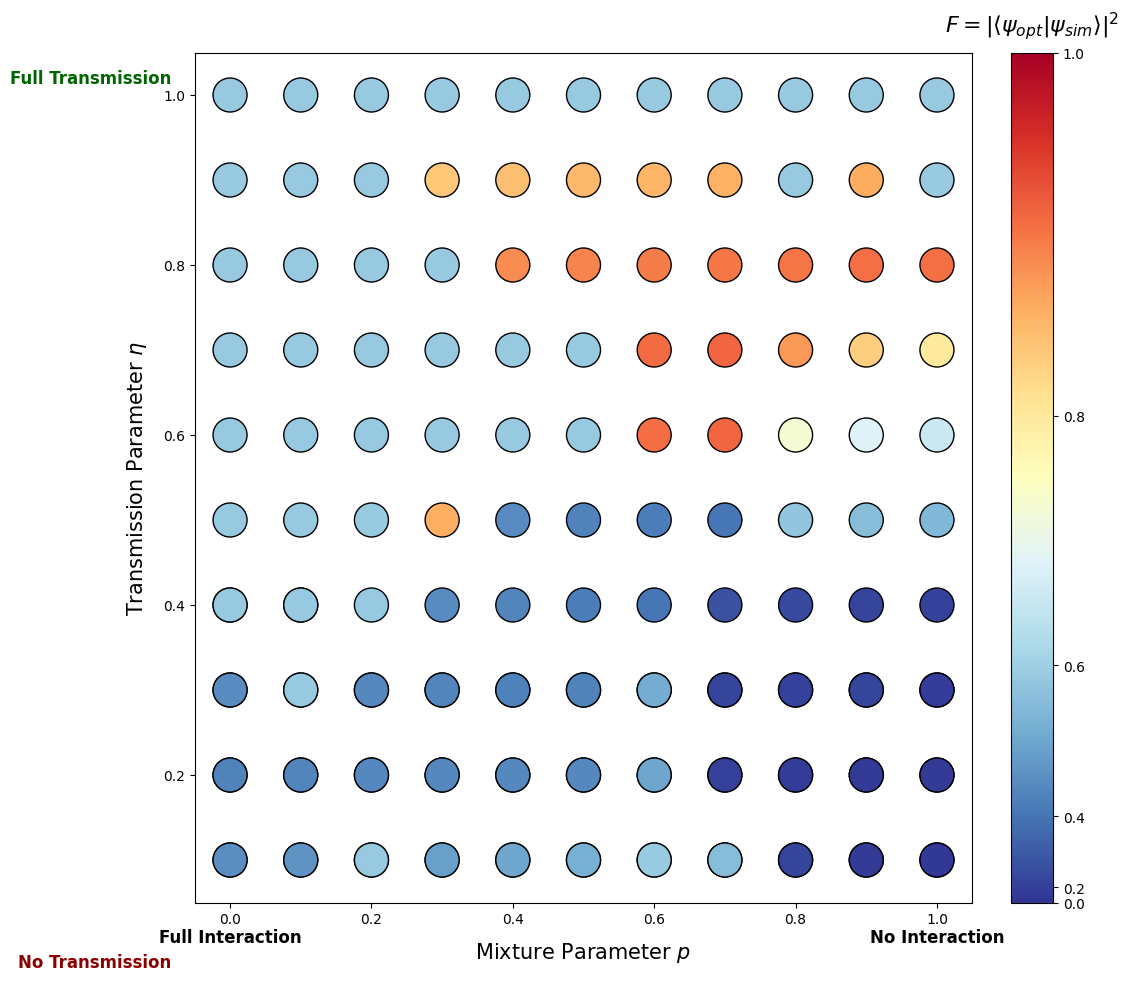

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import os
import re

def plot_final_research_map_refined(N_target, K_target, filename, gamma=2.5, save_path=None):
    if not os.path.exists(filename):
        print(f"Database file '{filename}' not found.")
        return

    # FORCE PYCHARM TO USE WHITE BACKGROUND
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.edgecolor': 'black'
    })

    df = pd.read_csv(filename)
    mask = (df['N'] == N_target) & (df['K'] == K_target)
    subset = df[mask].copy().dropna(subset=['coeffs'])
    if subset.empty: return

    def extract_first_float(s):
        clean_s = str(s).replace('np.float64(', '').replace(')', '')
        vals = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", clean_s)
        return float(vals[0]) if vals else 0.0

    subset['eta_scalar'] = subset['eta_vec'].apply(extract_first_float)
    subset['p'] = pd.to_numeric(subset['p'], errors='coerce')

    def generate_combinations_local(K, N):
        from itertools import product
        return [comb for comb in product(range(N + 1), repeat=K) if sum(comb) <= N]

    combs = generate_combinations_local(K_target, N_target)
    ref_combs_w = [tuple([0]*K_target)]
    for i in range(K_target):
        mode_fock = [0]*K_target
        mode_fock[i] = N_target
        ref_combs_w.append(tuple(mode_fock))

    # --- HUMPHREYS ET AL. TRUE OPTIMAL STATE ---
    d = K_target
    alpha = 1.0 / np.sqrt(d + np.sqrt(d))
    beta = np.sqrt(1.0 - d * (alpha**2))

    ref_opt = np.zeros(len(combs))
    indices_opt = [i for i, c in enumerate(combs) if c in ref_combs_w]

    # The reference mode |0,0> gets the beta amplitude
    ref_opt[indices_opt[0]] = beta
    # The phase modes |N,0> and |0,N> get the alpha amplitude
    for idx in indices_opt[1:]:
        ref_opt[idx] = alpha

    coeff_matrix = np.array([np.array([float(x) for x in str(row['coeffs']).split(',')]) for _, row in subset.iterrows()])

    # Calculate fidelity against the TRUE optimal state
    fidelities_sq = (coeff_matrix @ ref_opt)**2

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_alpha(1.0)

    norm = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=1)

    sc = ax.scatter(subset['p'], subset['eta_scalar'], c=fidelities_sq, s=600,
                    cmap='RdYlBu_r', norm=norm, edgecolors='black', zorder=3)

    ax.set_ylabel(r"Transmission Parameter $\eta$", fontsize=15, labelpad=10)
    ax.set_xlabel(r"Mixture Parameter $p$", fontsize=15, labelpad=10)

    # SHIFTED Y-COORDINATES: 1.02 for Full Transmission, -0.02 for No Transmission
    ax.text(-0.03, 1.02, "Full Transmission", transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontweight='bold', color='darkgreen', fontsize=12)
    ax.text(-0.03, -0.02, "No Transmission", transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontweight='bold', color='darkred', fontsize=12)
    ax.text(0.0, -0.03, "Full Interaction", transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontweight='bold', fontsize=12)
    ax.text(1.0, -0.03, "No Interaction", transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontweight='bold', fontsize=12)

    # CLEAN RHS COLORBAR
    cbar = plt.colorbar(sc, pad=0.04)
    cbar.ax.set_title(r"$F = |\langle \psi_{opt} | \psi_{sim} \rangle|^2$", fontsize=16, pad=15)
    # Standard numerical ticks only, removing all the dense textual states
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    # Removed the plt.title completely here!

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0.05, 1.05)

    plt.grid(True, linestyle=':', alpha=0.4)
    # Adjusted 'top' to 0.95 since the title is now gone
    plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    if save_path:
        plt.savefig(save_path, dpi=300, facecolor='white', transparent=False)
        print(f"  -> Saved heatmap to {save_path}")

    plt.show()

# Execute Heatmap Plotting
output_dir = "plots_output"
os.makedirs(output_dir, exist_ok=True)

print("Plotting the full 2D Fidelity Heatmap...")
plot_final_research_map_refined(
    N_target=3, K_target=2, filename="optimized_states_common_eta.csv",
    save_path=f"{output_dir}/heatmap_phase_transition.png"
)

In [19]:
def optimize_initial_state_crb(N, K, eta, p):
    """
    Optimizes the initial probe state to MINIMIZE the Cramér-Rao Bound (CRB).
    CRB is computed as the Trace of the inverse of the QFIM.
    """
    D = N + 1
    combinations = generate_combinations(K, N)
    num_coeffs = len(combinations)

    # FIX: Ensure eta is a list/vector, as N_tot expects an eta for each mode
    eta_vec = eta if isinstance(eta, (list, tuple, np.ndarray)) else [eta] * K

    generators = []
    for i in range(K):
        ops = [qeye(D)] * K
        ops[i] = num(D)
        generators.append(tensor(ops))

    basis_kets = []
    for comb in combinations:
        state_modes = [basis(D, n) for n in comb]
        basis_kets.append(tensor(state_modes))

    def objective(coeffs):
        norm = np.linalg.norm(coeffs)
        if norm < 1e-10: return 1e6

        initial_ket = sum((coeffs[i] / norm) * basis_kets[i] for i in range(num_coeffs))

        # Pass eta_vec instead of eta
        rho_out = N_tot(initial_ket, eta_vec, p, N, K)
        vals, vecs = diagonalize(rho_out)
        qfim = calculate_QFIM(rho_out, vals, vecs, generators)

        # Add a tiny regularization to avoid singular matrix inversion errors
        reg_qfim = qfim + np.eye(K) * 1e-12
        inv_qfim = np.linalg.pinv(reg_qfim)

        # Goal: Minimize the trace of the inverse QFIM (the true multiparameter CRB)
        return np.trace(inv_qfim)

    start_coeffs = np.array([1.0 / np.sqrt(num_coeffs)] * num_coeffs)
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x**2) - 1})
    bnds = [(0, 1) for _ in range(num_coeffs)]

    res = minimize(objective, start_coeffs, method='SLSQP', bounds=bnds, constraints=cons)

    # We return the Trace(QFIM) of the optimal state to keep the database and plotting backwards-compatible
    opt_coeffs = res.x
    norm = np.linalg.norm(opt_coeffs)
    initial_ket = sum((opt_coeffs[i] / norm) * basis_kets[i] for i in range(num_coeffs))

    # Pass eta_vec instead of eta here as well
    rho_out = N_tot(initial_ket, eta_vec, p, N, K)
    vals, vecs = diagonalize(rho_out)
    opt_qfim = calculate_QFIM(rho_out, vals, vecs, generators)
    max_qfi = np.trace(opt_qfim)

    return res.x, combinations, max_qfi


import pandas as pd

def save_simulation_results(master_results, N, K, filename="metrology_database_crb.csv"):
    """
    Parses the master_results dictionary and saves it to a CSV file.
    Format of master_results: { eta_value: [ {'p': float, 'max_qfi': float, 'coeffs': list, 'combinations': list}, ... ] }
    """
    rows = []
    for eta, data_list in master_results.items():
        for data in data_list:
            # Convert coefficients list to a comma-separated string
            coeffs_str = ",".join(map(str, data['coeffs']))
            # Convert combinations list of tuples to a semicolon-separated string
            combs_str = ";".join([",".join(map(str, comb)) for comb in data['combinations']])

            rows.append({
                'N': N,
                'K': K,
                'eta': eta,
                'p': data['p'],
                'max_qfi': data['max_qfi'],
                'coeffs': coeffs_str,
                'combinations': combs_str
            })

    # Convert to DataFrame and save
    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"Results successfully saved to {filename}")

In [20]:
import pandas as pd
import numpy as np
import os
import csv

def run_and_save_simulation_crb(N, K, eta_values, p_values, filename="metrology_database_crb.csv"):
    # 1. Load existing progress to avoid re-running
    completed = set()
    if os.path.exists(filename):
        try:
            df_existing = pd.read_csv(filename)
            # Find all the existing runs for this N and K
            mask = (df_existing['N'] == N) & (df_existing['K'] == K)
            for _, row in df_existing[mask].iterrows():
                # Extract eta safely
                e_val = float(row['eta'] if 'eta' in df_existing.columns else row['eta_vec'])
                p_val = float(row['p'])
                # Store rounded values to avoid floating point mismatch
                completed.add((round(e_val, 3), round(p_val, 3)))
        except Exception as e:
            print(f"Warning: Could not read existing database. Error: {e}")

    # 2. Open file in APPEND mode ('a') so it never overwrites
    file_exists = os.path.isfile(filename)

    with open(filename, mode='a', newline='') as f:
        writer = csv.writer(f)

        # Write headers if it's a brand new file
        if not file_exists or os.path.getsize(filename) == 0:
            writer.writerow(['N', 'K', 'eta', 'p', 'max_qfi', 'coeffs', 'combinations'])

        # 3. Iterate and optimize
        for eta in eta_values:
            eta_display = round(eta, 2)
            print(f"\n>>> Processing eta = {eta_display} (CRB Optimization)...")

            for p in p_values:
                # CHECK IF ALREADY CALCULATED
                if (round(eta, 3), round(p, 3)) in completed:
                    print(f"    p={p:.2f}: Already exists in database. Skipping...")
                    continue

                print(f"    p={p:.2f}: Optimizing...")
                opt_coeffs, combinations, max_qfi = optimize_initial_state_crb(N, K, eta, p)

                # Format the lists into strings for the CSV
                coeffs_str = ",".join(map(str, opt_coeffs.tolist()))
                combs_str = ";".join([",".join(map(str, comb)) for comb in combinations])

                # Write the single row to the CSV instantly
                writer.writerow([N, K, eta, p, max_qfi, coeffs_str, combs_str])
                f.flush() # Force the operating system to save to disk IMMEDIATELY

                # Add to completed set so we don't accidentally run it twice in the same loop
                completed.add((round(eta, 3), round(p, 3)))

# Define parameters for the run
N_param, K_param = 3, 2
eta_list_crb = [0.8, 0.85, 0.9, 0.95, 1.0]

# Feed it the ENTIRE list. It will skip what you already have and calculate the missing gaps.
p_list_full = np.round(np.linspace(0.0, 1.0, 11), 1)

# Execute
run_and_save_simulation_crb(N_param, K_param, eta_list_crb, p_list_full)
print("\nDatabase update complete!")


>>> Processing eta = 0.8 (CRB Optimization)...
    p=0.00: Already exists in database. Skipping...
    p=0.10: Already exists in database. Skipping...
    p=0.20: Already exists in database. Skipping...
    p=0.30: Already exists in database. Skipping...
    p=0.40: Already exists in database. Skipping...
    p=0.50: Already exists in database. Skipping...
    p=0.60: Already exists in database. Skipping...
    p=0.70: Already exists in database. Skipping...
    p=0.80: Already exists in database. Skipping...
    p=0.90: Already exists in database. Skipping...
    p=1.00: Already exists in database. Skipping...

>>> Processing eta = 0.85 (CRB Optimization)...
    p=0.00: Already exists in database. Skipping...
    p=0.10: Already exists in database. Skipping...
    p=0.20: Already exists in database. Skipping...
    p=0.30: Already exists in database. Skipping...
    p=0.40: Already exists in database. Skipping...
    p=0.50: Already exists in database. Skipping...
    p=0.60: Already

In [21]:
import numpy as np
from qutip import *
from itertools import product

def compute_numerical_multipixel_limits(N, K):
    """
    Constructs the theoretical optimal noiseless state from Humphreys 2013
    and pushes it through the numerical QFIM functions to find the exact computed bounds.
    """
    D = N + 1

    # 1. Calculate theoretical amplitudes
    alpha = 1.0 / np.sqrt(K + np.sqrt(K))
    beta = 1.0 / np.sqrt(1 + np.sqrt(K))

    # 2. Build combinations and basis kets
    combinations = [c for c in product(range(N + 1), repeat=K) if sum(c) <= N]
    basis_kets = [tensor([basis(D, n) for n in comb]) for comb in combinations]

    # 3. Assign amplitudes to the correct basis states
    coeffs = np.zeros(len(combinations))

    # Reference mode has all N particles -> signal modes are (0,0)
    idx_ref = combinations.index(tuple([0] * K))
    coeffs[idx_ref] = beta

    # Signal modes have all N particles one by one
    for i in range(K):
        comb_i = tuple([N if j == i else 0 for j in range(K)])
        idx_sig = combinations.index(comb_i)
        coeffs[idx_sig] = alpha

    coeffs = coeffs / np.linalg.norm(coeffs) # Normalize
    initial_ket = sum(coeffs[i] * basis_kets[i] for i in range(len(combinations)))

    # 4. Set up generators and noiseless channel (eta = 1.0, p = 0.0)
    generators = []
    for i in range(K):
        ops = [qeye(D)] * K
        ops[i] = num(D)
        generators.append(tensor(ops))

    eta_vec = [1.0] * K
    rho_out = N_tot(initial_ket, eta_vec, 0.0, N, K)

    # 5. Compute QFIM using your pipeline
    vals, vecs = diagonalize(rho_out)
    qfim = calculate_QFIM(rho_out, vals, vecs, generators)

    multipixel_qfi = np.trace(qfim)
    multipixel_crb = (K**2) / multipixel_qfi

    return multipixel_qfi, multipixel_crb

# Compute and save as global variables for the plots
COMPUTED_MULTIPIXEL_QFI, COMPUTED_MULTIPIXEL_CRB = compute_numerical_multipixel_limits(3, 2)

# Calculate analytical for printing comparison
analytical_qfi = (4 * 3**2) / (2 * (1 + np.sqrt(2))**2)
analytical_crb = (2 * (1 + np.sqrt(2))**2) / (4 * 3**2)

print("--- Noiseless Limit Verification (eta=1.0) ---")
print(f"Computed Multipixel QFI   : {COMPUTED_MULTIPIXEL_QFI:.6f}")
print(f"Analytical Multipixel QFI : {analytical_qfi:.6f}")
print("----------------------------------------------")
print(f"Computed Multipixel CRB   : {COMPUTED_MULTIPIXEL_CRB:.6f}")
print(f"Analytical Multipixel CRB : {analytical_crb:.6f}")

--- Noiseless Limit Verification (eta=1.0) ---
Computed Multipixel QFI   : 14.911688
Analytical Multipixel QFI : 3.088312
----------------------------------------------
Computed Multipixel CRB   : 0.268246
Analytical Multipixel CRB : 0.323802



--- Generating 1D Plots for CRB Optimized States ---
Plotting CRB Optimized for Eta 0.8...
  -> Saved figure to plots_crb_output/crb_opt_eta_0.8_custom_axi_RHS_legend.png


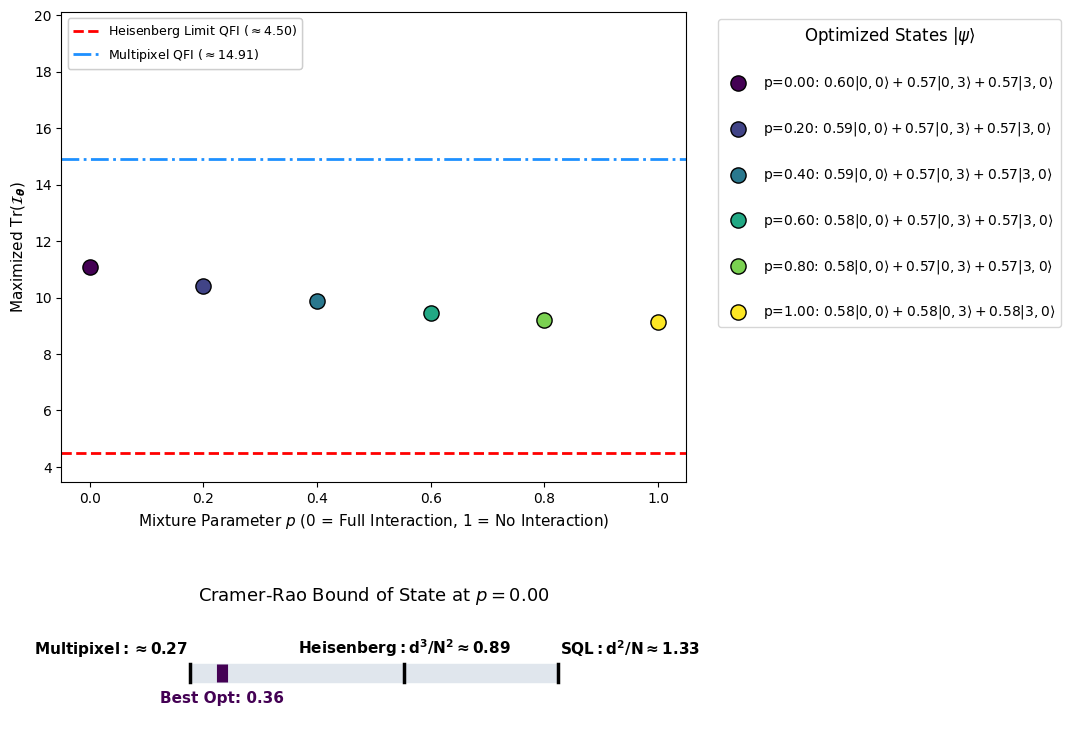

Plotting CRB Optimized for Eta 0.85...
  -> Saved figure to plots_crb_output/crb_opt_eta_0.85_custom_axi_RHS_legend.png


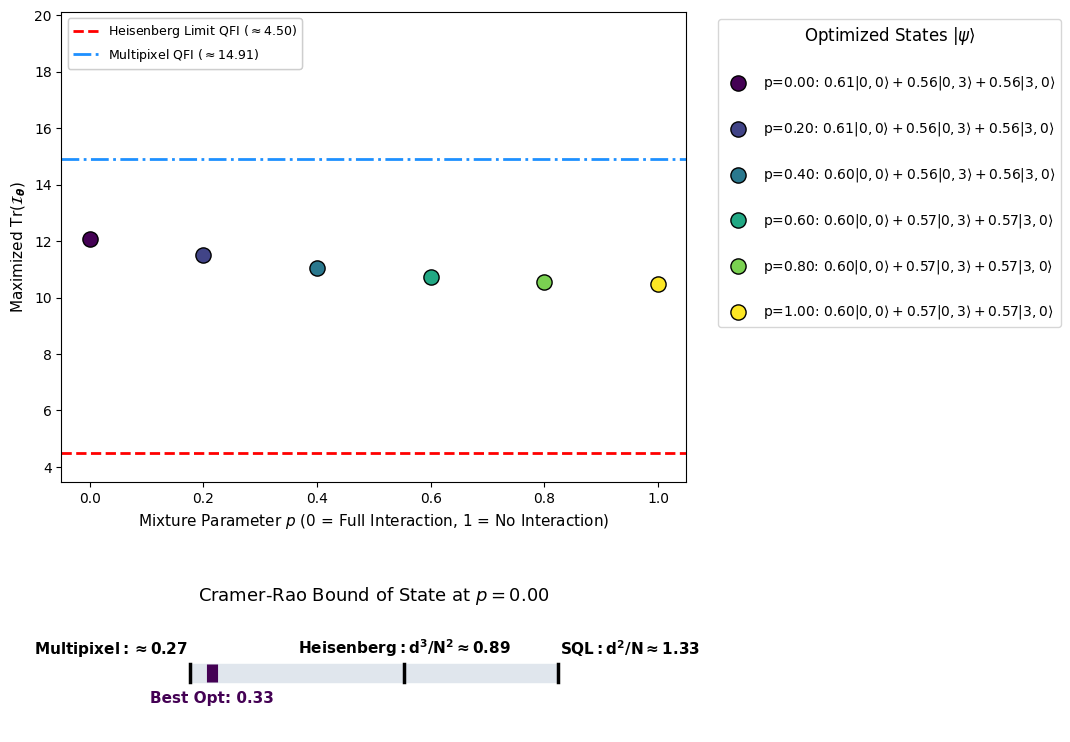

Plotting CRB Optimized for Eta 0.9...
  -> Saved figure to plots_crb_output/crb_opt_eta_0.9_custom_axi_RHS_legend.png


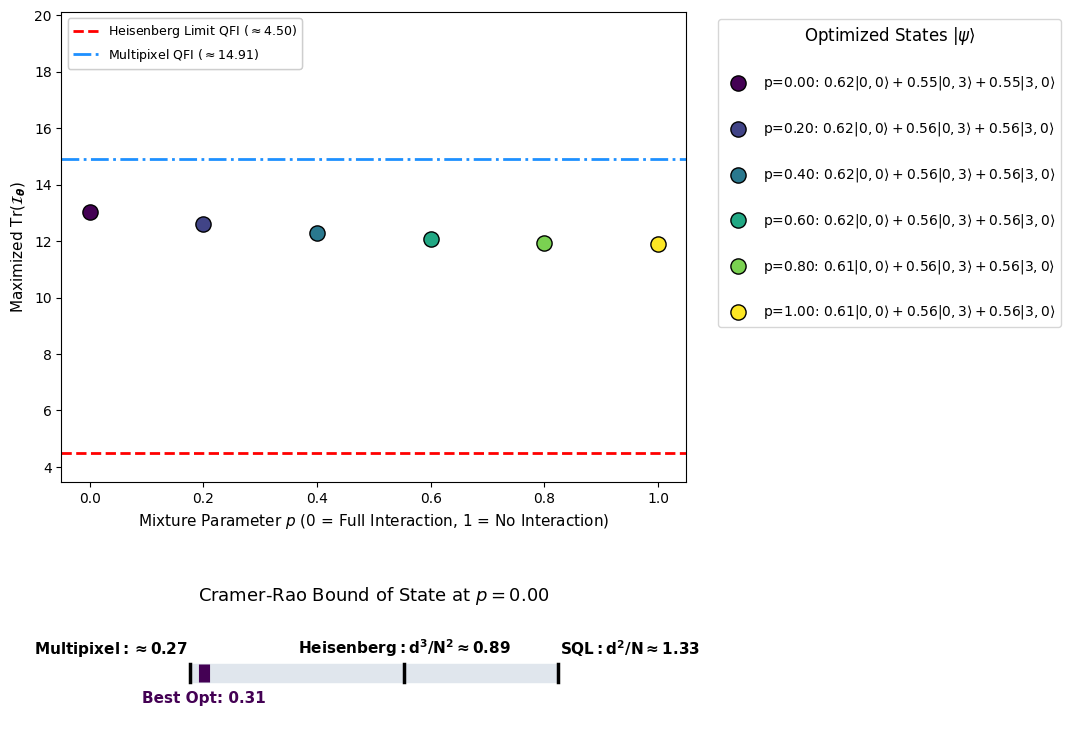

Plotting CRB Optimized for Eta 0.95...
  -> Saved figure to plots_crb_output/crb_opt_eta_0.95_custom_axi_RHS_legend.png


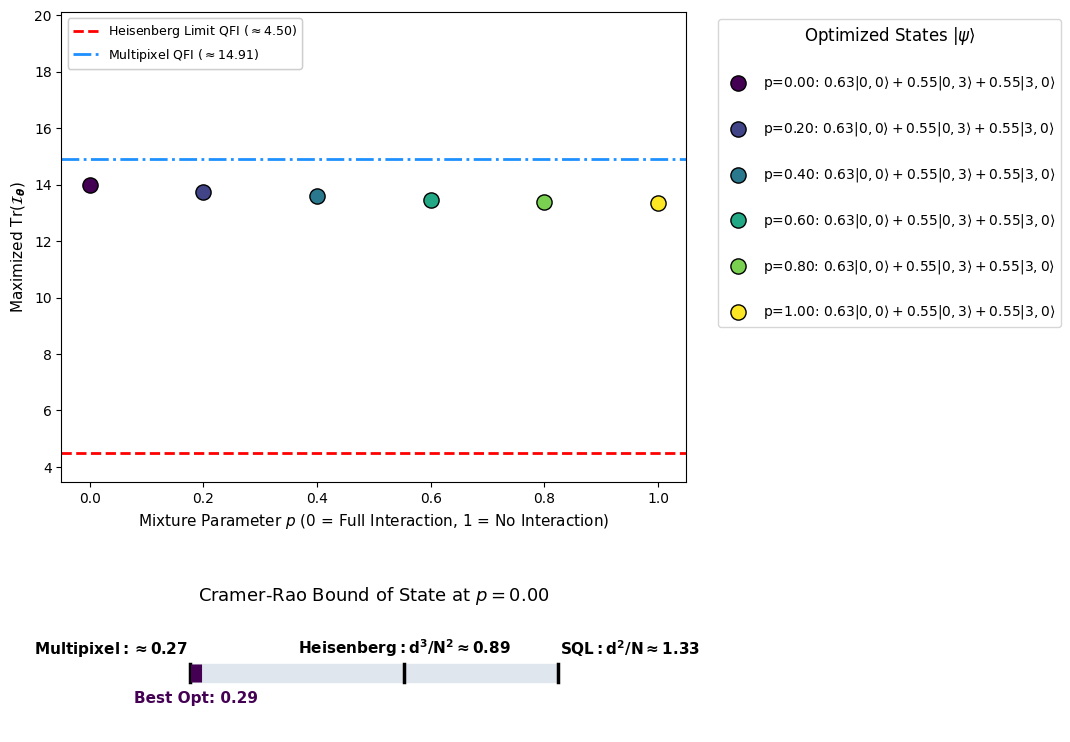

Plotting CRB Optimized for Eta 1.0...
  -> Saved figure to plots_crb_output/crb_opt_eta_1.0_custom_axi_RHS_legend.png


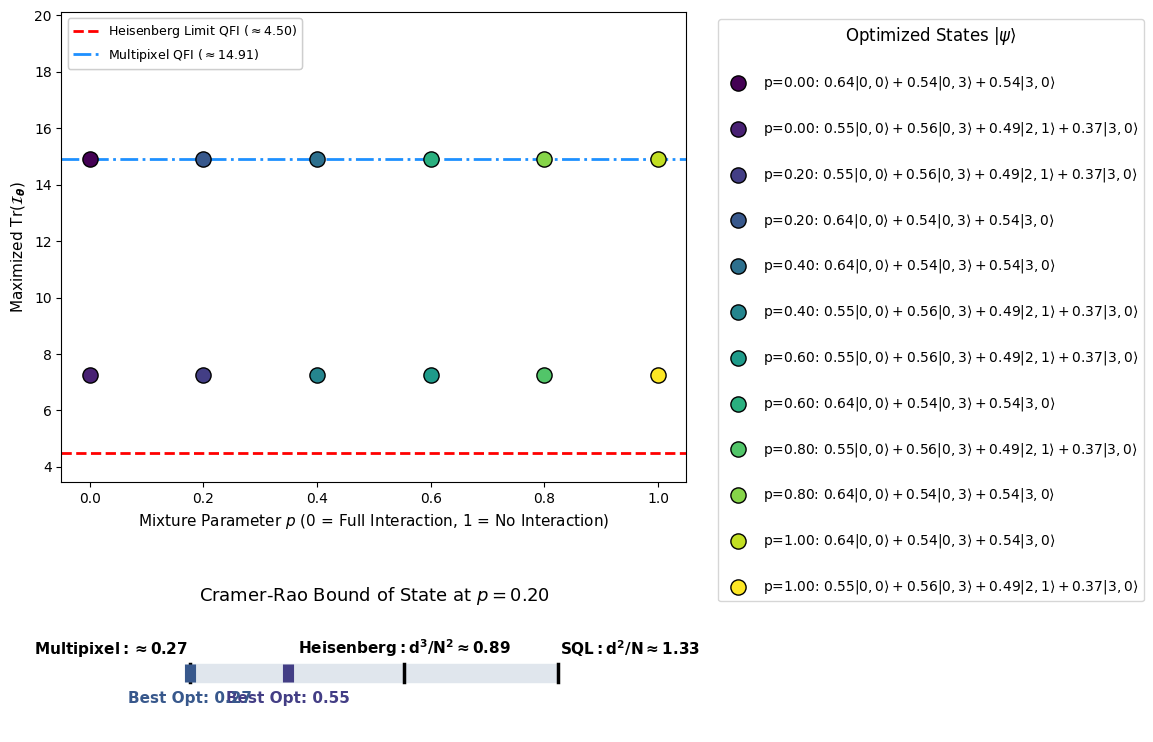

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
from matplotlib.gridspec import GridSpec

def format_ket_latex(coeffs, combinations, threshold=1e-2):
    terms = []
    for c, comb in zip(coeffs, combinations):
        if np.abs(c) > threshold:
            basis_str = f"|{','.join(map(str, comb))}\\rangle"
            terms.append(f"{c:.2f}{basis_str}")

    if not terms: return "$0$"
    chunks = [terms[i:i + 5] for i in range(0, len(terms), 5)]
    lines = []
    for i, chunk in enumerate(chunks):
        if i == 0: lines.append(f"${' + '.join(chunk)}$")
        else: lines.append(f"$+ {' + '.join(chunk)}$")
    return "\n".join(lines)

def plot_from_database_crb(N_target, K_target, eta_vec_target, filename, save_path=None, forced_size=None, hide_legend=False, hide_benchmark_labels=False):
    if not os.path.exists(filename):
        return None

    plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})

    df = pd.read_csv(filename)
    target_scalar = float(eta_vec_target[0])

    def is_eta_match(s):
        clean_s = str(s).replace('np.float64(', '').replace(')', '')
        vals = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", clean_s)
        if not vals: return False
        return np.isclose(float(vals[0]), target_scalar, atol=1e-3)

    p_targets = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    mask = (df['N'] == N_target) & (df['K'] == K_target) & \
           (df['eta'] if 'eta' in df.columns else df['eta_vec']).apply(is_eta_match) & \
           (df['p'].apply(lambda x: any(np.isclose(x, pt, atol=0.01) for pt in p_targets)))

    subset = df[mask].sort_values(by='p')
    if subset.empty: return None

    # --- IDENTIFY THE BEST OPTIMIZED STATE ---
    best_idx = subset['max_qfi'].idxmax()
    best_p = subset.loc[best_idx, 'p']
    best_qfi = subset.loc[best_idx, 'max_qfi']

    current_size = forced_size if forced_size else 8.0

    # WIDENED FIGURE: Added 3.5 to the width to act as a dedicated space for the RHS legend,
    # preventing the main plots from getting horizontally squished!
    fig = plt.figure(figsize=(current_size + 3.5, current_size))
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.45)
    ax_qfi = fig.add_subplot(gs[0])
    ax_var = fig.add_subplot(gs[1])

    d, N = K_target, N_target
    sql_val = (d**2) / N
    noon_val = (d**3) / (N**2)

    # RESTORED: Exactly using your global notebook variables
    computed_multipixel_crb = COMPUTED_MULTIPIXEL_CRB
    computed_multipixel_qfi = COMPUTED_MULTIPIXEL_QFI

    computed_bound = sql_val
    for _, row in subset.iterrows():
        if np.isclose(row['p'], 0.0, atol=0.01) and row['max_qfi'] > 0:
            computed_bound = (d**2) / row['max_qfi']
            break

    best_crb = (d**2) / best_qfi

    # --- WIDEN MARGINS TO PUSH TEXT OUTWARDS ---
    lhs_bound = min(computed_multipixel_crb, computed_bound, best_crb)
    rhs_bound = max(sql_val, computed_bound, best_crb)

    margin = (rhs_bound - lhs_bound) * 0.35
    if margin == 0: margin = 0.1
    ax_var.set_xlim(lhs_bound - margin, rhs_bound + margin)
    ax_var.set_ylim(-1.0, 1.0)
    bar_height = 0.15
    ax_var.fill_between([lhs_bound, rhs_bound], -bar_height, bar_height, color='#E0E6ED', zorder=1)

    benchmarks = [computed_multipixel_crb, noon_val, sql_val]
    benchmark_labels = [
        rf"$\mathbf{{Multipixel: \approx {computed_multipixel_crb:.2f}}}$",
        rf"$\mathbf{{Heisenberg: d^3/N^2 \approx {noon_val:.2f}}}$",
        rf"$\mathbf{{SQL: d^2/N \approx {sql_val:.2f}}}$"
    ]

    colors = plt.cm.viridis(np.linspace(0, 1, len(subset)))
    qfis = subset['max_qfi'].values

    # --- DRAW THE BENCHMARKS ---
    for i, (val, label) in enumerate(zip(benchmarks, benchmark_labels)):
        ax_var.plot([val, val], [-bar_height, bar_height], color='black', linewidth=2.5, zorder=2)
        if not hide_benchmark_labels:
            if i == 0:
                ax_var.text(val - margin*0.02, bar_height + 0.1, label, color='black', fontsize=11, ha='right', va='bottom')
            elif i == 2:
                ax_var.text(val + margin*0.02, bar_height + 0.1, label, color='black', fontsize=11, ha='left', va='bottom')
            else:
                ax_var.text(val, bar_height + 0.1, label, color='black', fontsize=11, ha='center', va='bottom')

    # --- PLOT SCATTER ---
    for i, (idx, row) in enumerate(subset.iterrows()):
        p_val = row['p']
        qfi_val = row['max_qfi']
        var_val = (d**2) / qfi_val
        coeffs = [float(x) for x in str(row['coeffs']).split(',')]
        combs = [tuple(map(int, c.split(','))) for c in str(row['combinations']).split(';')]

        latex_ket = format_ket_latex(coeffs, combs)
        legend_label = f"p={p_val:.2f}: {latex_ket}"

        ax_qfi.scatter(p_val, qfi_val, label=legend_label, s=120, color=colors[i], edgecolors='black', zorder=5)

        if np.isclose(p_val, best_p, atol=0.01):
            ax_var.plot([var_val, var_val], [-bar_height, bar_height], color=colors[i], linewidth=8, solid_capstyle='butt', zorder=5)
            ax_var.text(var_val, -bar_height - 0.15, rf"Best Opt: {var_val:.2f}", color=colors[i], fontsize=11, ha='center', va='top', weight='bold')

    hl_qfi_val = (d**2) / noon_val

    ax_qfi.axhline(y=hl_qfi_val, color='red', linestyle='--', linewidth=2, zorder=2, label=rf"Heisenberg Limit QFI ($\approx {hl_qfi_val:.2f}$)")
    ax_qfi.axhline(y=computed_multipixel_qfi, color='dodgerblue', linestyle='-.', linewidth=2, zorder=2, label=rf"Multipixel QFI ($\approx {computed_multipixel_qfi:.2f}$)")

    # --- EXTEND Y-AXIS DRAMATICALLY FOR LEGEND CLEARANCE ---
    all_qfi_values = list(qfis) + [hl_qfi_val, computed_multipixel_qfi]
    if len(all_qfi_values) > 0:
        q_min, q_max = np.min(all_qfi_values), np.max(all_qfi_values)
        if q_max == q_min: q_min -= 1; q_max += 1
        ax_qfi.set_ylim(q_min - 0.1*(q_max-q_min), q_max + 0.5*(q_max-q_min))

    ax_qfi.set_xlabel(r"Mixture Parameter $p$ (0 = Full Interaction, 1 = No Interaction)", fontsize=11)
    ax_qfi.set_ylabel(r"Maximized $\mathrm{Tr}(\mathcal{I}_{\boldsymbol{\theta}})$", fontsize=11)
    ax_qfi.grid(True, linestyle=':', alpha=0.4)

    ax_var.set_yticks([]); ax_var.spines['left'].set_visible(False)
    ax_var.spines['right'].set_visible(False); ax_var.spines['top'].set_visible(False)
    ax_var.spines['bottom'].set_visible(False); ax_var.set_xticks([])
    ax_var.set_title(rf"Cramer-Rao Bound of State at $p={best_p:.2f}$", fontsize=13, pad=10)

    # Limit legends (Top Left inside the plot)
    handles_qfi, labels_qfi = ax_qfi.get_legend_handles_labels()
    line_handles = [h for h, l in zip(handles_qfi, labels_qfi) if "QFI" in l]
    line_labels = [l for l in labels_qfi if "QFI" in l]

    limit_legend = ax_qfi.legend(line_handles, line_labels, loc='upper left', fontsize=9, frameon=True, facecolor='white', framealpha=0.9)
    ax_qfi.add_artist(limit_legend)

    # --- FIXED RIGHT-HAND SIDE LEGEND ---
    if not hide_legend:
        handles, labels = ax_qfi.get_legend_handles_labels()
        state_handles_labels = [(h, l) for h, l in zip(handles, labels) if "QFI" not in l]
        if state_handles_labels:
            sh, sl = zip(*state_handles_labels)

            # Shrunk the right bound to exactly 0.60 so the plot leaves space for the legend.
            # Kept top=0.95, which is exactly where we will pin the legend.
            plt.subplots_adjust(left=0.10, bottom=0.15, right=0.60, top=0.95)

            # Switched to fig.legend so it never gets buried or overridden by the axis.
            # bbox_to_anchor=(0.62, 0.95) places it right next to the plot border (0.60)
            # and perfectly aligns the top edges (0.95).
            states_legend = fig.legend(sh, sl, title=rf"Optimized States $|\psi\rangle$",
                                       loc='upper left', bbox_to_anchor=(0.62, 0.95),
                                       fontsize=10, frameon=True, facecolor='white',
                                       ncol=1, title_fontsize='12', labelspacing=2.0)
    else:
        plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.95)

    if forced_size is None:
        fig.canvas.draw()
        bbox = fig.get_tightbbox(fig.canvas.get_renderer())
        plt.close(fig)
        return bbox.width, bbox.height
    else:
        if save_path:
            plt.savefig(save_path, dpi=300, facecolor='white', transparent=False, bbox_inches='tight')
            print(f"  -> Saved figure to {save_path}")
        plt.show()
        return None

# Execution Block for 1D Plots
eta_list_crb = [0.8, 0.85, 0.9, 0.95, 1.0]
output_dir_crb = "plots_crb_output"
os.makedirs(output_dir_crb, exist_ok=True)

print("\n--- Generating 1D Plots for CRB Optimized States ---")
for e in eta_list_crb:
    print(f"Plotting CRB Optimized for Eta {e}...")
    plot_from_database_crb(N_target=3, K_target=2, eta_vec_target=[e, e], filename="metrology_database_crb.csv",
                           save_path=f"{output_dir_crb}/crb_opt_eta_{e}_custom_axi_RHS_legend.png",
                           forced_size=9.0)

Saved Combined Heatmap to plots_crb_output\crb_combined_fidelity_heatmap_fixed.png


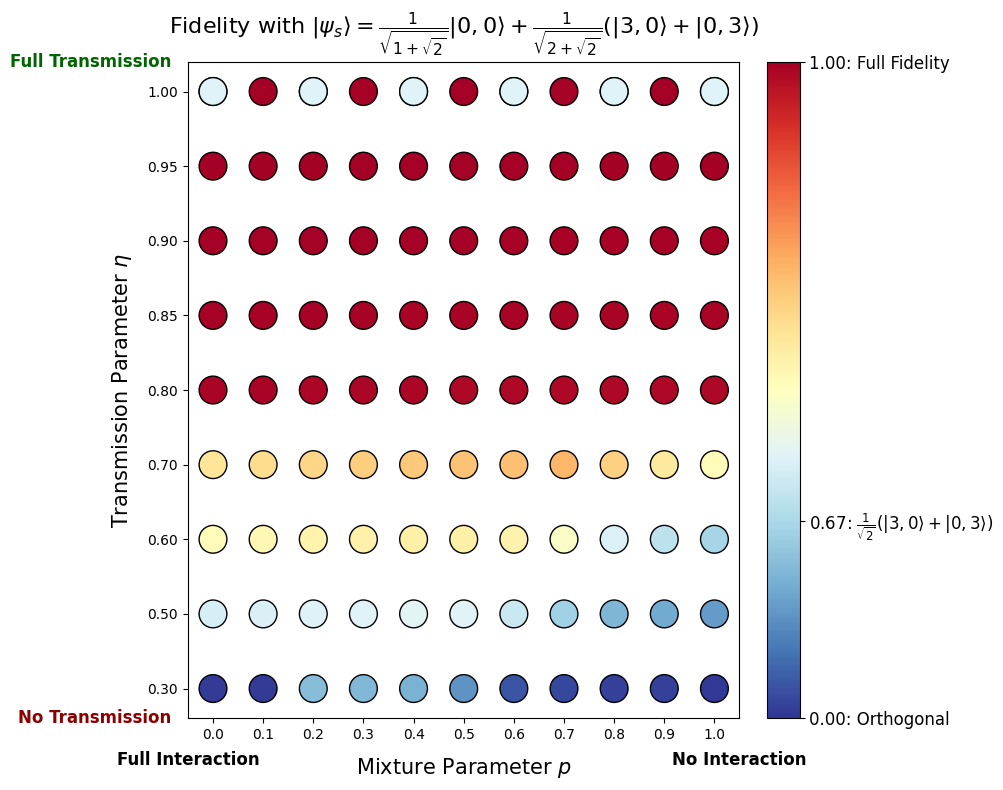

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import matplotlib.colors as mcolors

def plot_combined_heatmap(N_target, K_target, old_db, new_db, save_folder):
    os.makedirs(save_folder, exist_ok=True)

    df_old = pd.read_csv(old_db) if os.path.exists(old_db) else pd.DataFrame()
    df_new = pd.read_csv(new_db) if os.path.exists(new_db) else pd.DataFrame()

    # Define the exact domains for each database to prevent overlapping bad data
    etas_old = [0.3, 0.5, 0.6, 0.7]
    etas_new = [0.8, 0.85, 0.9, 0.95, 1.0]
    all_etas_sorted = sorted(etas_old + etas_new)

    def clean_eta(x):
        try:
            if isinstance(x, str):
                vals = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", x.replace('np.float64(', '').replace(')', ''))
                if vals: return float(vals[0])
            return float(x)
        except:
            return np.nan

    # 1. Process Old Database (STRICTLY for eta <= 0.7)
    subset_old = pd.DataFrame()
    if not df_old.empty:
        col_name_old = 'eta' if 'eta' in df_old.columns else 'eta_vec'
        df_old['unified_eta'] = df_old[col_name_old].apply(clean_eta)
        mask_old = (df_old['N'] == N_target) & (df_old['K'] == K_target) & \
                   (df_old['unified_eta'].apply(lambda e: any(np.isclose(e, tgt, atol=1e-3) for tgt in etas_old)))
        subset_old = df_old[mask_old].copy()

    # 2. Process New Database (STRICTLY for eta >= 0.8)
    subset_new = pd.DataFrame()
    if not df_new.empty:
        col_name_new = 'eta' if 'eta' in df_new.columns else 'eta_vec'
        df_new['unified_eta'] = df_new[col_name_new].apply(clean_eta)
        mask_new = (df_new['N'] == N_target) & (df_new['K'] == K_target) & \
                   (df_new['unified_eta'].apply(lambda e: any(np.isclose(e, tgt, atol=1e-3) for tgt in etas_new)))
        subset_new = df_new[mask_new].copy()

    # Combine cleanly without overlaps
    subset = pd.concat([subset_old, subset_new]).dropna(subset=['coeffs'])

    if subset.empty:
        print("No data to plot for the heatmap.")
        return

    # Filter to exact requested p values (0.0, 0.1, ..., 1.0)
    p_targets = np.round(np.linspace(0.0, 1.0, 11), 1)
    subset = subset[subset['p'].apply(lambda p_val: any(np.isclose(p_val, pt, atol=0.01) for pt in p_targets))]

    # Create uniform Y-axis indices (0 to 8) to fix visual spacing gaps
    def get_eta_index(e):
        for i, target in enumerate(all_etas_sorted):
            if np.isclose(e, target, atol=1e-3):
                return i
        return -1
    subset['y_index'] = subset['unified_eta'].apply(get_eta_index)

    # 3. Construct the EXACT Analytical \psi_s from Humphreys 2013
    alpha = 1.0 / np.sqrt(K_target + np.sqrt(K_target))
    beta = 1.0 / np.sqrt(1 + np.sqrt(K_target))

    fidelities_sq = []
    for _, row in subset.iterrows():
        # Using absolute value safeguards against global negative phases from the solver
        coeffs = np.abs(np.array([float(x) for x in str(row['coeffs']).split(',')]))
        row_combs = [tuple(map(int, c.split(','))) for c in str(row['combinations']).split(';')]

        temp_ref = np.zeros(len(row_combs))

        # Build reference vector aligned with the combination index
        if tuple([0] * K_target) in row_combs:
            temp_ref[row_combs.index(tuple([0] * K_target))] = beta
        for i in range(K_target):
            comb_i = tuple([N_target if j == i else 0 for j in range(K_target)])
            if comb_i in row_combs:
                temp_ref[row_combs.index(comb_i)] = alpha

        fid = (np.dot(coeffs, temp_ref))**2
        fidelities_sq.append(min(fid, 1.0))

    # --- PLOTTING EXACTLY LIKE THE ORIGINAL IMAGE ---
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.rcParams['axes.facecolor'] = 'white'

    norm = mcolors.PowerNorm(gamma=3.0, vmin=0, vmax=1)

    # Scatter using the uniform 'y_index' to force perfect grid layout
    sc = ax.scatter(subset['p'], subset['y_index'], c=fidelities_sq, s=400,
                    cmap='RdYlBu_r', norm=norm, edgecolors='black', zorder=3)

    # Relabel the uniform Y-axis back to the actual Eta float values
    ax.set_yticks(range(len(all_etas_sorted)))
    ax.set_yticklabels([f"{eta:.2f}" for eta in all_etas_sorted])

    # Clean X-axis labels
    ax.set_xticks(p_targets)
    ax.set_xticklabels([f"{p:.1f}" for p in p_targets])

    ax.set_ylabel(r"Transmission Parameter $\eta$", fontsize=15, labelpad=10)
    ax.set_xlabel(r"Mixture Parameter $p$", fontsize=15, labelpad=10)

    # Border Texts
    ax.text(-0.03, 1.0, "Full Transmission", transform=ax.transAxes,
            ha='right', va='center', fontweight='bold', color='darkgreen', fontsize=12)
    ax.text(-0.03, 0.0, "No Transmission", transform=ax.transAxes,
            ha='right', va='center', fontweight='bold', color='darkred', fontsize=12)

    ax.text(0.0, -0.05, "Full Interaction", transform=ax.transAxes,
            ha='center', va='top', fontweight='bold', fontsize=12)
    ax.text(1.0, -0.05, "No Interaction", transform=ax.transAxes,
            ha='center', va='top', fontweight='bold', fontsize=12)

    # Title with updated Ket notation
    ax.set_title(r"Fidelity with $|\psi_s\rangle = \frac{1}{\sqrt{1+\sqrt{2}}}|0,0\rangle + \frac{1}{\sqrt{2+\sqrt{2}}}(|3,0\rangle + |0,3\rangle)$", fontsize=16, pad=20)

    # Original Colorbar
    cbar = plt.colorbar(sc, pad=0.04)
    cbar.set_ticks([0.0, 0.67, 1.0])
    cbar.set_ticklabels([
        "0.00: Orthogonal",
        r"0.67: $\frac{1}{\sqrt{2}}(|3,0\rangle + |0,3\rangle)$",
        "1.00: Full Fidelity"
    ], fontsize=12)

    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    save_path = os.path.join(save_folder, "crb_combined_fidelity_heatmap_fixed.png")
    plt.savefig(save_path, dpi=300, facecolor='white')
    print(f"Saved Combined Heatmap to {save_path}")
    plt.show()

# Execute Heatmap Plotting
plot_combined_heatmap(3, 2, "metrology_database.csv", "metrology_database_crb.csv", "plots_crb_output")

Saved Combined Heatmap to plots_crb_output\crb_combined_fidelity_heatmap_gamma3_no_03.png


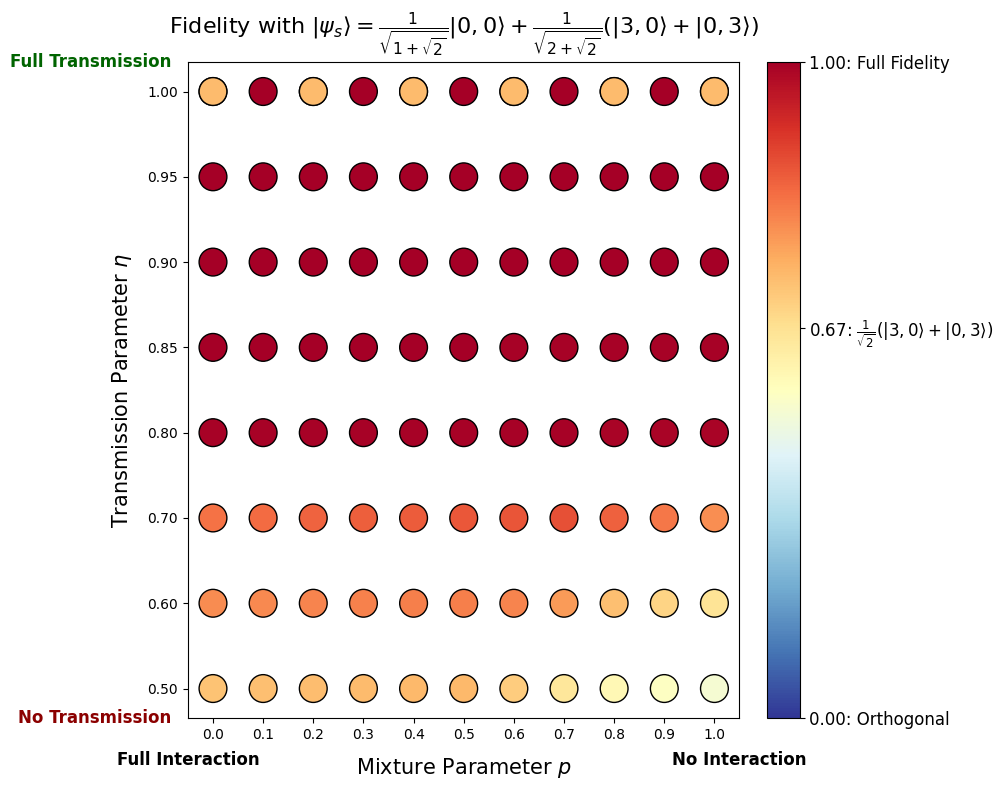

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import matplotlib.colors as mcolors

def plot_combined_heatmap(N_target, K_target, old_db, new_db, save_folder):
    os.makedirs(save_folder, exist_ok=True)

    df_old = pd.read_csv(old_db) if os.path.exists(old_db) else pd.DataFrame()
    df_new = pd.read_csv(new_db) if os.path.exists(new_db) else pd.DataFrame()

    # Define the exact domains for each database (Removed 0.3 from etas_old)
    etas_old = [0.5, 0.6, 0.7]
    etas_new = [0.8, 0.85, 0.9, 0.95, 1.0]
    all_etas_sorted = sorted(etas_old + etas_new)

    def clean_eta(x):
        try:
            if isinstance(x, str):
                vals = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", x.replace('np.float64(', '').replace(')', ''))
                if vals: return float(vals[0])
            return float(x)
        except:
            return np.nan

    # 1. Process Old Database (STRICTLY for eta <= 0.7)
    subset_old = pd.DataFrame()
    if not df_old.empty:
        col_name_old = 'eta' if 'eta' in df_old.columns else 'eta_vec'
        df_old['unified_eta'] = df_old[col_name_old].apply(clean_eta)
        mask_old = (df_old['N'] == N_target) & (df_old['K'] == K_target) & \
                   (df_old['unified_eta'].apply(lambda e: any(np.isclose(e, tgt, atol=1e-3) for tgt in etas_old)))
        subset_old = df_old[mask_old].copy()

    # 2. Process New Database (STRICTLY for eta >= 0.8)
    subset_new = pd.DataFrame()
    if not df_new.empty:
        col_name_new = 'eta' if 'eta' in df_new.columns else 'eta_vec'
        df_new['unified_eta'] = df_new[col_name_new].apply(clean_eta)
        mask_new = (df_new['N'] == N_target) & (df_new['K'] == K_target) & \
                   (df_new['unified_eta'].apply(lambda e: any(np.isclose(e, tgt, atol=1e-3) for tgt in etas_new)))
        subset_new = df_new[mask_new].copy()

    # Combine cleanly without overlaps
    subset = pd.concat([subset_old, subset_new]).dropna(subset=['coeffs'])

    if subset.empty:
        print("No data to plot for the heatmap.")
        return

    # Filter to exact requested p values (0.0, 0.1, ..., 1.0)
    p_targets = np.round(np.linspace(0.0, 1.0, 11), 1)
    subset = subset[subset['p'].apply(lambda p_val: any(np.isclose(p_val, pt, atol=0.01) for pt in p_targets))]

    # Create uniform Y-axis indices to fix visual spacing gaps
    def get_eta_index(e):
        for i, target in enumerate(all_etas_sorted):
            if np.isclose(e, target, atol=1e-3):
                return i
        return -1
    subset['y_index'] = subset['unified_eta'].apply(get_eta_index)

    # 3. Construct the EXACT Analytical \psi_s from Humphreys 2013
    alpha = 1.0 / np.sqrt(K_target + np.sqrt(K_target))
    beta = 1.0 / np.sqrt(1 + np.sqrt(K_target))

    fidelities_sq = []
    for _, row in subset.iterrows():
        # Using absolute value safeguards against global negative phases from the solver
        coeffs = np.abs(np.array([float(x) for x in str(row['coeffs']).split(',')]))
        row_combs = [tuple(map(int, c.split(','))) for c in str(row['combinations']).split(';')]

        temp_ref = np.zeros(len(row_combs))

        # Build reference vector aligned with the combination index
        if tuple([0] * K_target) in row_combs:
            temp_ref[row_combs.index(tuple([0] * K_target))] = beta
        for i in range(K_target):
            comb_i = tuple([N_target if j == i else 0 for j in range(K_target)])
            if comb_i in row_combs:
                temp_ref[row_combs.index(comb_i)] = alpha

        fid = (np.dot(coeffs, temp_ref))**2
        fidelities_sq.append(min(fid, 1.0))

    # --- PLOTTING EXACTLY LIKE THE ORIGINAL IMAGE ---
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.rcParams['axes.facecolor'] = 'white'

    # Gamma set to 3.0 to increase sensitivity at higher fidelities
    norm = mcolors.PowerNorm(gamma=1.3, vmin=0, vmax=1)

    # Scatter using the uniform 'y_index' to force perfect grid layout
    sc = ax.scatter(subset['p'], subset['y_index'], c=fidelities_sq, s=400,
                    cmap='RdYlBu_r', norm=norm, edgecolors='black', zorder=3)

    # Relabel the uniform Y-axis back to the actual Eta float values
    ax.set_yticks(range(len(all_etas_sorted)))
    ax.set_yticklabels([f"{eta:.2f}" for eta in all_etas_sorted])

    # Clean X-axis labels
    ax.set_xticks(p_targets)
    ax.set_xticklabels([f"{p:.1f}" for p in p_targets])

    ax.set_ylabel(r"Transmission Parameter $\eta$", fontsize=15, labelpad=10)
    ax.set_xlabel(r"Mixture Parameter $p$", fontsize=15, labelpad=10)

    # Border Texts
    ax.text(-0.03, 1.0, "Full Transmission", transform=ax.transAxes,
            ha='right', va='center', fontweight='bold', color='darkgreen', fontsize=12)
    ax.text(-0.03, 0.0, "No Transmission", transform=ax.transAxes,
            ha='right', va='center', fontweight='bold', color='darkred', fontsize=12)

    ax.text(0.0, -0.05, "Full Interaction", transform=ax.transAxes,
            ha='center', va='top', fontweight='bold', fontsize=12)
    ax.text(1.0, -0.05, "No Interaction", transform=ax.transAxes,
            ha='center', va='top', fontweight='bold', fontsize=12)

    # Title with updated Ket notation
    ax.set_title(r"Fidelity with $|\psi_s\rangle = \frac{1}{\sqrt{1+\sqrt{2}}}|0,0\rangle + \frac{1}{\sqrt{2+\sqrt{2}}}(|3,0\rangle + |0,3\rangle)$", fontsize=16, pad=20)

    # Original Colorbar
    cbar = plt.colorbar(sc, pad=0.04)
    cbar.set_ticks([0.0, 0.67, 1.0])
    cbar.set_ticklabels([
        "0.00: Orthogonal",
        r"0.67: $\frac{1}{\sqrt{2}}(|3,0\rangle + |0,3\rangle)$",
        "1.00: Full Fidelity"
    ], fontsize=12)

    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()

    # Save as a NEW file to prevent overwriting the old one
    save_path = os.path.join(save_folder, "crb_combined_fidelity_heatmap_gamma3_no_03.png")
    plt.savefig(save_path, dpi=300, facecolor='white')
    print(f"Saved Combined Heatmap to {save_path}")
    plt.show()

# Execute Heatmap Plotting
plot_combined_heatmap(3, 2, "metrology_database.csv", "metrology_database_crb.csv", "plots_crb_output")

In [25]:
import pandas as pd
import numpy as np
import re
import os

def generate_word_report_table(db_path, output_csv, N_target=3, K_target=2):
    if not os.path.exists(db_path):
        print(f"File {db_path} not found.")
        return

    df = pd.read_csv(db_path)
    df.columns = df.columns.str.strip()

    if 'max_qfi' not in df.columns:
        print("ERROR: Could not find the 'max_qfi' column.")
        return

    def clean_eta(x):
        try:
            if isinstance(x, str):
                vals = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", x.replace('np.float64(', '').replace(')', ''))
                if vals: return float(vals[0])
            return float(x)
        except:
            return np.nan

    eta_col = 'eta' if 'eta' in df.columns else 'eta_vec'
    df['unified_eta'] = df[eta_col].apply(clean_eta)

    target_p_values = [0.0, 0.5, 1.0]

    mask = (
        (df['N'] == N_target) &
        (df['K'] == K_target) &
        (df['unified_eta'] >= 0.79) &
        (df['p'].apply(lambda x: any(np.isclose(x, pt, atol=0.01) for pt in target_p_values)))
    )
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print("No data found for the specified N, K, eta, and p targets.")
        return

    d = K_target

    # --- QFI NORMALIZATION ---
    # Find the absolute highest QFI across the entire dataset (your reference limit at eta = 1.0)
    reference_qfi = df_filtered['max_qfi'].max()

    results = []

    for (eta, p), group in df_filtered.groupby(['unified_eta', 'p']):
        best_qfi = group['max_qfi'].max()
        best_crb = (d**2) / best_qfi

        # Calculate Percentage directly from QFI:
        # (Current State's QFI / The Absolute Best QFI) * 100
        qfi_pct = (best_qfi / reference_qfi) * 100

        results.append({
            'Eta (\eta)': np.round(eta, 2),
            'Mixture (p)': np.round(p, 1),
            'Max QFI': np.round(best_qfi, 4),
            'Optimal CRB': np.round(best_crb, 5),
            '% of Reference QFI': f"{np.round(qfi_pct, 2)}%"
        })

    results_df = pd.DataFrame(results).sort_values(by=['Eta (\eta)', 'Mixture (p)'])
    results_df.to_csv(output_csv, index=False)

    print(f"\nReport saved to: {output_csv}\n")
    print("--- DATA FOR YOUR WORD REPORT ---")
    print(results_df.to_string(index=False))

# Run the extraction
generate_word_report_table(
    db_path="metrology_database_crb.csv",
    output_csv="report_table_data_qfi_normalized.csv",
    N_target=3,
    K_target=2
)


Report saved to: report_table_data_qfi_normalized.csv

--- DATA FOR YOUR WORD REPORT ---
 Eta (\eta)  Mixture (p)  Max QFI  Optimal CRB % of Reference QFI
       0.80          0.0  11.1006      0.36034             74.43%
       0.80          0.5   9.6519      0.41443             64.72%
       0.80          1.0   9.1256      0.43833             61.19%
       0.85          0.0  12.0681      0.33145             80.92%
       0.85          0.5  10.8873      0.36740              73.0%
       0.85          1.0  10.4714      0.38199             70.21%
       0.90          0.0  13.0242      0.30712             87.33%
       0.90          0.5  12.1752      0.32854             81.63%
       0.90          1.0  11.8842      0.33658             79.68%
       0.95          0.0  13.9710      0.28631             93.67%
       0.95          0.5  13.5171      0.29592             90.63%
       0.95          1.0  13.3655      0.29928             89.62%
       1.00          0.0  14.9143      0.26820      


 PHASE 1: COMPUTATION (Varying Eta Only)

>>> OPTIMIZING for varying eta = [1.0, 0.5] ...
    p=0.00: Already exists in database. Skipping...
    p=0.20: Already exists in database. Skipping...
    p=0.40: Already exists in database. Skipping...
    p=0.60: Already exists in database. Skipping...
    p=0.80: Already exists in database. Skipping...
    p=1.00: Already exists in database. Skipping...

 PHASE 2: GENERATING PLOTS
Generating Plot for Optimized Varying Eta [1.0, 0.5]...
  -> Saved figure to plots_crb_output/crb_opt_eta_1.0_0.5_RHS_legend.png


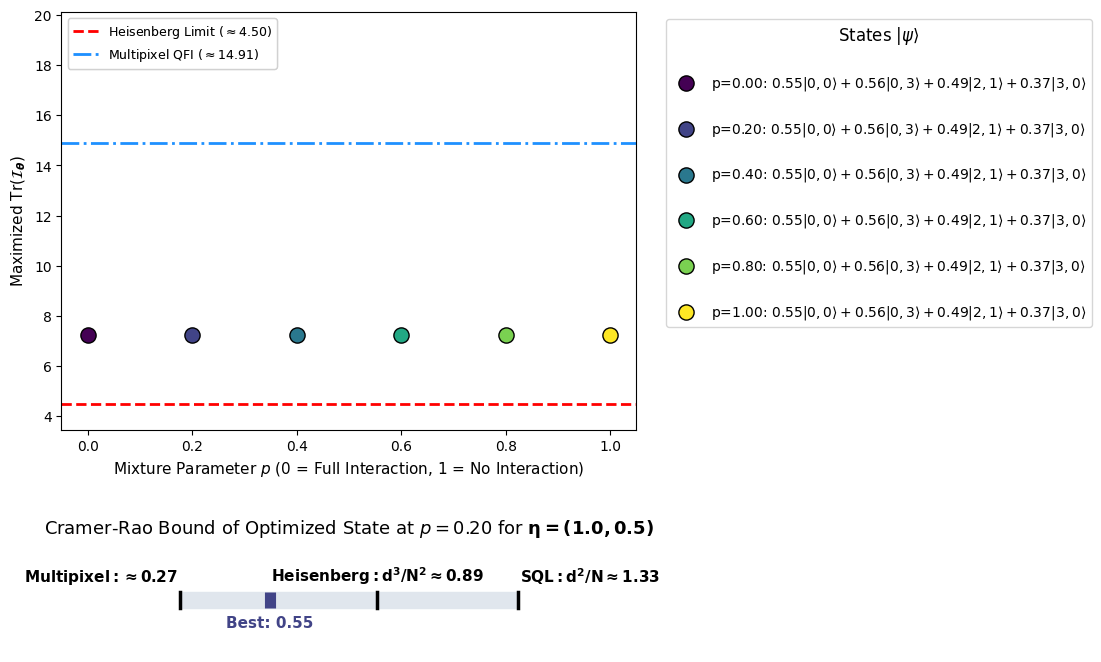


Generating Plot for Uniform State Eta 0.9...
No data found to plot for eta=0.9

All tasks complete!


In [26]:
import pandas as pd
import numpy as np
import os
import csv
import re
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ====================================================================
# 1. OPTIMIZATION ENGINE (Varying Eta Only)
# ====================================================================
def run_optimization_varying_eta(N, K, eta_vec, p_values, filename="metrology_database_crb.csv"):
    completed = set()
    if os.path.exists(filename):
        try:
            df_existing = pd.read_csv(filename)
            mask = (df_existing['N'] == N) & (df_existing['K'] == K)
            for _, row in df_existing[mask].iterrows():
                e_str = str(row['eta'] if 'eta' in df_existing.columns else row['eta_vec']).replace(' ', '')
                completed.add((e_str, round(float(row['p']), 3)))
        except Exception:
            pass

    file_exists = os.path.isfile(filename)
    with open(filename, mode='a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists or os.path.getsize(filename) == 0:
            writer.writerow(['N', 'K', 'eta', 'p', 'max_qfi', 'coeffs', 'combinations'])

        eta_str_clean = str(eta_vec).replace(' ', '')
        print(f"\n>>> OPTIMIZING for varying eta = {eta_vec} ...")
        for p in p_values:
            if (eta_str_clean, round(p, 3)) in completed:
                print(f"    p={p:.2f}: Already exists in database. Skipping...")
                continue

            print(f"    p={p:.2f}: Optimizing...")
            # Calls your global physics backend
            opt_coeffs, combinations, max_qfi = optimize_initial_state_crb(N, K, eta_vec, p)

            coeffs_str = ",".join(map(str, opt_coeffs.tolist()))
            combs_str = ";".join([",".join(map(str, comb)) for comb in combinations])
            writer.writerow([N, K, str(eta_vec), p, max_qfi, coeffs_str, combs_str])
            f.flush()

# ====================================================================
# 2. PLOTTING ENGINE (Unified RHS Format)
# ====================================================================
def format_ket_latex(coeffs, combinations, threshold=1e-2):
    terms = []
    for c, comb in zip(coeffs, combinations):
        if np.abs(c) > threshold:
            basis_str = f"|{','.join(map(str, comb))}\\rangle"
            terms.append(f"{c:.2f}{basis_str}")

    if not terms: return "$0$"
    chunks = [terms[i:i + 5] for i in range(0, len(terms), 5)]
    lines = []
    for i, chunk in enumerate(chunks):
        if i == 0: lines.append(f"${' + '.join(chunk)}$")
        else: lines.append(f"$+ {' + '.join(chunk)}$")
    return "\n".join(lines)

def plot_custom_format(N_target, K_target, eta_target, filename, is_uniform=False, save_path=None):
    if not os.path.exists(filename):
        print(f"File {filename} not found.")
        return

    plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
    df = pd.read_csv(filename)

    def is_eta_match(s):
        clean_s = str(s).replace('np.float64(', '').replace(')', '').replace('[', '').replace(']', '')
        vals = [float(v) for v in re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", clean_s)]
        if not vals: return False

        target_vals = eta_target if isinstance(eta_target, list) else [eta_target]
        if len(vals) == 1: return all(np.isclose(vals[0], t, atol=1e-3) for t in target_vals)
        if len(vals) >= len(target_vals): return all(np.isclose(p, t, atol=1e-3) for p, t in zip(vals, target_vals))
        return False

    eta_col = 'eta' if 'eta' in df.columns else 'eta_vec'
    p_targets = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    mask = (df['N'] == N_target) & (df['K'] == K_target) & (df[eta_col].apply(is_eta_match)) & (df['p'].apply(lambda x: any(np.isclose(x, pt, atol=0.01) for pt in p_targets)))

    subset = df[mask].sort_values(by='p')
    if subset.empty:
        print(f"No data found to plot for eta={eta_target}")
        return

    best_idx = subset['max_qfi'].idxmax()
    best_p = subset.loc[best_idx, 'p']
    best_qfi = subset.loc[best_idx, 'max_qfi']

    # WIDENED FIGURE for the RHS Legend
    fig = plt.figure(figsize=(11.5, 8.0))
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.45)
    ax_qfi = fig.add_subplot(gs[0])
    ax_var = fig.add_subplot(gs[1])

    d, N = K_target, N_target
    sql_val = (d**2) / N
    noon_val = (d**3) / (N**2)

    computed_multipixel_crb = COMPUTED_MULTIPIXEL_CRB if 'COMPUTED_MULTIPIXEL_CRB' in globals() else sql_val
    computed_multipixel_qfi = COMPUTED_MULTIPIXEL_QFI if 'COMPUTED_MULTIPIXEL_QFI' in globals() else (d**2)/sql_val

    best_crb = (d**2) / best_qfi
    computed_bound = (d**2) / subset[np.isclose(subset['p'], 0.0)]['max_qfi'].values[0] if 0.0 in subset['p'].values else best_crb

    lhs_bound = min(computed_multipixel_crb, computed_bound, best_crb)
    rhs_bound = max(sql_val, computed_bound, best_crb)
    margin = max((rhs_bound - lhs_bound) * 0.35, 0.1)

    ax_var.set_xlim(lhs_bound - margin, rhs_bound + margin)
    ax_var.set_ylim(-1.0, 1.0)
    bar_height = 0.15
    ax_var.fill_between([lhs_bound, rhs_bound], -bar_height, bar_height, color='#E0E6ED', zorder=1)

    benchmarks = [computed_multipixel_crb, noon_val, sql_val]
    benchmark_labels = [
        rf"$\mathbf{{Multipixel: \approx {computed_multipixel_crb:.2f}}}$",
        rf"$\mathbf{{Heisenberg: d^3/N^2 \approx {noon_val:.2f}}}$",
        rf"$\mathbf{{SQL: d^2/N \approx {sql_val:.2f}}}$"
    ]

    for i, (val, label) in enumerate(zip(benchmarks, benchmark_labels)):
        ax_var.plot([val, val], [-bar_height, bar_height], color='black', linewidth=2.5, zorder=2)
        ha_align = 'right' if i == 0 else ('left' if i == 2 else 'center')
        offset = -margin*0.02 if i == 0 else (margin*0.02 if i == 2 else 0)
        ax_var.text(val + offset, bar_height + 0.1, label, color='black', fontsize=11, ha=ha_align, va='bottom')

    # Uniform states get a solid color, optimized states get the gradient
    colors = ['dodgerblue'] * len(subset) if is_uniform else plt.cm.viridis(np.linspace(0, 1, len(subset)))
    unique_legend_added = False

    for i, (_, row) in enumerate(subset.iterrows()):
        p_val = row['p']
        qfi_val = row['max_qfi']
        var_val = (d**2) / qfi_val
        coeffs = [float(x) for x in str(row['coeffs']).split(',')]
        combs = [tuple(map(int, c.split(','))) for c in str(row['combinations']).split(';')]

        latex_ket = format_ket_latex(coeffs, combs)

        if is_uniform:
            legend_label = f"Uniform State: {latex_ket}" if not unique_legend_added else None
            unique_legend_added = True
        else:
            legend_label = f"p={p_val:.2f}: {latex_ket}"

        ax_qfi.scatter(p_val, qfi_val, label=legend_label, s=120, color=colors[i], edgecolors='black', zorder=5)

        if np.isclose(p_val, best_p, atol=0.01) or (is_uniform and np.isclose(p_val, 0.0)):
            marker_color = colors[i]
            ax_var.plot([var_val, var_val], [-bar_height, bar_height], color=marker_color, linewidth=8, solid_capstyle='butt', zorder=5)
            ax_var.text(var_val, -bar_height - 0.15, rf"Best: {var_val:.2f}", color=marker_color, fontsize=11, ha='center', va='top', weight='bold')

    hl_qfi_val = (d**2) / noon_val
    ax_qfi.axhline(y=hl_qfi_val, color='red', linestyle='--', linewidth=2, zorder=2, label=rf"Heisenberg Limit ($\approx {hl_qfi_val:.2f}$)")
    ax_qfi.axhline(y=computed_multipixel_qfi, color='dodgerblue', linestyle='-.', linewidth=2, zorder=2, label=rf"Multipixel QFI ($\approx {computed_multipixel_qfi:.2f}$)")

    all_qfi = list(subset['max_qfi'].values) + [hl_qfi_val, computed_multipixel_qfi]
    q_min, q_max = min(all_qfi), max(all_qfi)
    ax_qfi.set_ylim(q_min - 0.1*(q_max-q_min), q_max + 0.5*(q_max-q_min))

    ax_qfi.set_xlabel(r"Mixture Parameter $p$ (0 = Full Interaction, 1 = No Interaction)", fontsize=11)
    ax_qfi.set_ylabel(r"Maximized $\mathrm{Tr}(\mathcal{I}_{\boldsymbol{\theta}})$", fontsize=11)
    ax_qfi.grid(True, linestyle=':', alpha=0.4)

    eta_str = f"({eta_target[0]}, {eta_target[1]})" if isinstance(eta_target, list) else f"{eta_target}"
    title_prefix = "Uniform Superposition State" if is_uniform else f"Optimized State at $p={best_p:.2f}$"
    ax_var.set_title(rf"Cramer-Rao Bound of {title_prefix} for $\mathbf{{\eta={eta_str}}}$", fontsize=13, pad=10)

    ax_var.set_yticks([]); ax_var.set_xticks([])
    for spine in ['left', 'right', 'top', 'bottom']: ax_var.spines[spine].set_visible(False)

    handles, labels = ax_qfi.get_legend_handles_labels()
    line_h, line_l = zip(*[(h, l) for h, l in zip(handles, labels) if "Limit" in l or "Multipixel" in l])
    ax_qfi.add_artist(ax_qfi.legend(line_h, line_l, loc='upper left', fontsize=9, frameon=True, facecolor='white'))

    state_h, state_l = zip(*[(h, l) for h, l in zip(handles, labels) if "Limit" not in l and "Multipixel" not in l])
    plt.subplots_adjust(left=0.10, bottom=0.15, right=0.60, top=0.95)

    fig.legend(state_h, state_l, title=rf"States $|\psi\rangle$",
               loc='upper left', bbox_to_anchor=(0.62, 0.95),
               fontsize=10, frameon=True, facecolor='white',
               ncol=1, title_fontsize='12', labelspacing=2.0)

    if save_path:
        plt.savefig(save_path, dpi=300, facecolor='white', transparent=False, bbox_inches='tight')
        print(f"  -> Saved figure to {save_path}")
    plt.show()

# ====================================================================
# 3. MASTER EXECUTION BLOCK
# ====================================================================
N_param, K_param = 3, 2
output_dir = "plots_crb_output"
os.makedirs(output_dir, exist_ok=True)

# Point this to wherever your states are currently saved
opt_db = "metrology_database_crb.csv"
uni_db = "uniform_state_database.csv" if os.path.exists("uniform_state_database.csv") else opt_db

p_targets = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print("\n========================================================")
print(" PHASE 1: COMPUTATION (Varying Eta Only)")
print("========================================================")
varying_eta = [1.0, 0.5]
run_optimization_varying_eta(N_param, K_param, varying_eta, p_targets, opt_db)

print("\n========================================================")
print(" PHASE 2: GENERATING PLOTS")
print("========================================================")
print(f"Generating Plot for Optimized Varying Eta {varying_eta}...")
plot_custom_format(N_param, K_param, varying_eta, opt_db, is_uniform=False,
                   save_path=f"{output_dir}/crb_opt_eta_1.0_0.5_RHS_legend.png")

uniform_eta = 0.9
print(f"\nGenerating Plot for Uniform State Eta {uniform_eta}...")
plot_custom_format(N_param, K_param, uniform_eta, uni_db, is_uniform=True,
                   save_path=f"{output_dir}/crb_uni_eta_0.9_RHS_legend.png")

print("\nAll tasks complete!")


 PHASE 1: EVALUATING UNIFORM SUPERPOSITION STATE (N=3, K=2)

>>> Processing eta = 0.9 (Uniform State Evaluation)...
    p=0.00: Already exists in database. Skipping...
    p=0.20: Already exists in database. Skipping...
    p=0.40: Already exists in database. Skipping...
    p=0.60: Already exists in database. Skipping...
    p=0.80: Already exists in database. Skipping...
    p=1.00: Already exists in database. Skipping...

Database update complete!

 PHASE 2: GENERATING PLOTS
Plotting Uniform Superposition for Eta 0.9...
  -> Saved figure to plots_crb_output/crb_uni_eta_0.9_clean_layout.png


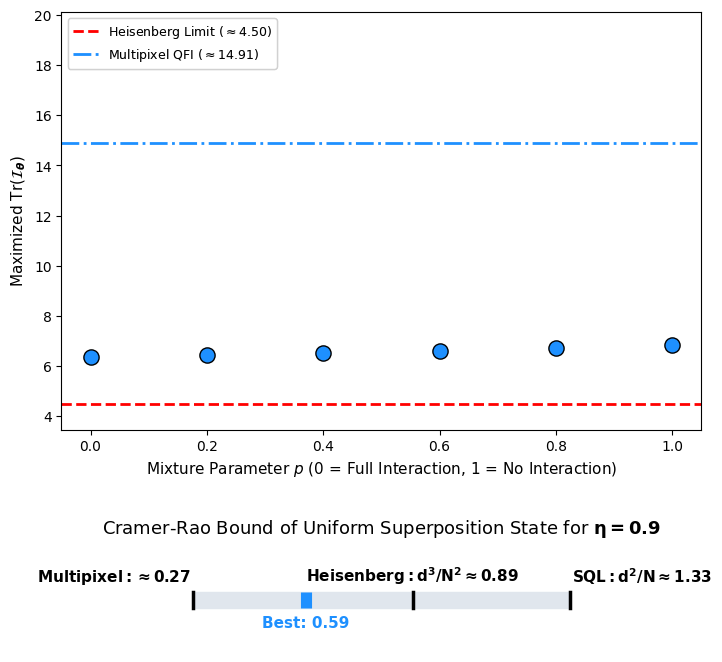

In [30]:
import pandas as pd
import numpy as np
import os
import csv
import re
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ====================================================================
# 1. EVALUATION ENGINE (Uniform Superposition Only - No Optimization)
# ====================================================================

def evaluate_uniform_state_crb(N, K, eta, p):
    """
    Evaluates the QFI and CRB for a UNIFORM superposition of the generated Fock states.
    No optimization is performed.
    """
    D = N + 1
    combinations = generate_combinations(K, N)
    num_coeffs = len(combinations)

    eta_vec = eta if isinstance(eta, (list, tuple, np.ndarray)) else [eta] * K

    generators = []
    for i in range(K):
        ops = [qeye(D)] * K
        ops[i] = num(D)
        generators.append(tensor(ops))

    basis_kets = []
    for comb in combinations:
        state_modes = [basis(D, n) for n in comb]
        basis_kets.append(tensor(state_modes))

    # Create uniform superposition: 1/sqrt(num_coeffs) for all states
    coeffs = np.array([1.0 / np.sqrt(num_coeffs)] * num_coeffs)
    norm = np.linalg.norm(coeffs)
    initial_ket = sum((coeffs[i] / norm) * basis_kets[i] for i in range(num_coeffs))

    rho_out = N_tot(initial_ket, eta_vec, p, N, K)
    vals, vecs = diagonalize(rho_out)
    qfim = calculate_QFIM(rho_out, vals, vecs, generators)

    # Return trace of QFIM to maintain database compatibility
    max_qfi = np.trace(qfim)

    return coeffs, combinations, max_qfi


def run_and_save_uniform_crb(N, K, eta_values, p_values, filename="uniform_state_database.csv"):
    completed = set()
    if os.path.exists(filename):
        try:
            df_existing = pd.read_csv(filename)
            mask = (df_existing['N'] == N) & (df_existing['K'] == K)
            for _, row in df_existing[mask].iterrows():
                e_val = float(row['eta'] if 'eta' in df_existing.columns else row['eta_vec'])
                p_val = float(row['p'])
                completed.add((round(e_val, 3), round(p_val, 3)))
        except Exception as e:
            pass

    file_exists = os.path.isfile(filename)

    with open(filename, mode='a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists or os.path.getsize(filename) == 0:
            writer.writerow(['N', 'K', 'eta', 'p', 'max_qfi', 'coeffs', 'combinations'])

        for eta in eta_values:
            eta_display = round(eta, 2)
            print(f"\n>>> Processing eta = {eta_display} (Uniform State Evaluation)...")

            for p in p_values:
                if (round(eta, 3), round(p, 3)) in completed:
                    print(f"    p={p:.2f}: Already exists in database. Skipping...")
                    continue

                print(f"    p={p:.2f}: Evaluating...")
                coeffs, combinations, max_qfi = evaluate_uniform_state_crb(N, K, eta, p)

                coeffs_str = ",".join(map(str, coeffs.tolist()))
                combs_str = ";".join([",".join(map(str, comb)) for comb in combinations])

                writer.writerow([N, K, eta, p, max_qfi, coeffs_str, combs_str])
                f.flush()


# ====================================================================
# 2. PLOTTING ENGINE (Clean Layout)
# ====================================================================

def format_ket_latex(coeffs, combinations, threshold=1e-2):
    terms = []
    for c, comb in zip(coeffs, combinations):
        if np.abs(c) > threshold:
            basis_str = f"|{','.join(map(str, comb))}\\rangle"
            terms.append(f"{c:.2f}{basis_str}")

    if not terms: return "$0$"
    chunks = [terms[i:i + 5] for i in range(0, len(terms), 5)]
    lines = []
    for i, chunk in enumerate(chunks):
        if i == 0: lines.append(f"${' + '.join(chunk)}$")
        else: lines.append(f"$+ {' + '.join(chunk)}$")
    return "\n".join(lines)

def plot_custom_format(N_target, K_target, eta_target, filename, is_uniform=False, save_path=None):
    if not os.path.exists(filename):
        print(f"File {filename} not found.")
        return

    plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
    df = pd.read_csv(filename)

    def is_eta_match(s):
        clean_s = str(s).replace('np.float64(', '').replace(')', '').replace('[', '').replace(']', '')
        vals = [float(v) for v in re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", clean_s)]
        if not vals: return False

        target_vals = eta_target if isinstance(eta_target, list) else [eta_target]
        if len(vals) == 1: return all(np.isclose(vals[0], t, atol=1e-3) for t in target_vals)
        if len(vals) >= len(target_vals): return all(np.isclose(p, t, atol=1e-3) for p, t in zip(vals, target_vals))
        return False

    eta_col = 'eta' if 'eta' in df.columns else 'eta_vec'
    p_targets = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    mask = (df['N'] == N_target) & (df['K'] == K_target) & (df[eta_col].apply(is_eta_match)) & (df['p'].apply(lambda x: any(np.isclose(x, pt, atol=0.01) for pt in p_targets)))

    subset = df[mask].sort_values(by='p')
    if subset.empty:
        print(f"No data found to plot for eta={eta_target}")
        return

    # Identify the absolute best state for the ONE CRB mark
    best_idx = subset['max_qfi'].idxmax()
    best_p = subset.loc[best_idx, 'p']
    best_qfi = subset.loc[best_idx, 'max_qfi']
    best_var_val = (d**2) / best_qfi if 'd' in locals() else (K_target**2) / best_qfi

    # Formatting: If uniform, we don't need extra width for the side legend
    current_size = 8.0
    fig_width = current_size if is_uniform else current_size + 3.5
    fig = plt.figure(figsize=(fig_width, current_size))

    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.45)
    ax_qfi = fig.add_subplot(gs[0])
    ax_var = fig.add_subplot(gs[1])

    d, N = K_target, N_target
    sql_val = (d**2) / N
    noon_val = (d**3) / (N**2)

    computed_multipixel_crb = COMPUTED_MULTIPIXEL_CRB if 'COMPUTED_MULTIPIXEL_CRB' in globals() else sql_val
    computed_multipixel_qfi = COMPUTED_MULTIPIXEL_QFI if 'COMPUTED_MULTIPIXEL_QFI' in globals() else (d**2)/sql_val

    best_crb = (d**2) / best_qfi
    computed_bound = (d**2) / subset[np.isclose(subset['p'], 0.0)]['max_qfi'].values[0] if 0.0 in subset['p'].values else best_crb

    lhs_bound = min(computed_multipixel_crb, computed_bound, best_crb)
    rhs_bound = max(sql_val, computed_bound, best_crb)
    margin = max((rhs_bound - lhs_bound) * 0.35, 0.1)

    ax_var.set_xlim(lhs_bound - margin, rhs_bound + margin)
    ax_var.set_ylim(-1.0, 1.0)
    bar_height = 0.15
    ax_var.fill_between([lhs_bound, rhs_bound], -bar_height, bar_height, color='#E0E6ED', zorder=1)

    benchmarks = [computed_multipixel_crb, noon_val, sql_val]
    benchmark_labels = [
        rf"$\mathbf{{Multipixel: \approx {computed_multipixel_crb:.2f}}}$",
        rf"$\mathbf{{Heisenberg: d^3/N^2 \approx {noon_val:.2f}}}$",
        rf"$\mathbf{{SQL: d^2/N \approx {sql_val:.2f}}}$"
    ]

    for i, (val, label) in enumerate(zip(benchmarks, benchmark_labels)):
        ax_var.plot([val, val], [-bar_height, bar_height], color='black', linewidth=2.5, zorder=2)
        ha_align = 'right' if i == 0 else ('left' if i == 2 else 'center')
        offset = -margin*0.02 if i == 0 else (margin*0.02 if i == 2 else 0)
        ax_var.text(val + offset, bar_height + 0.1, label, color='black', fontsize=11, ha=ha_align, va='bottom')

    colors = ['dodgerblue'] * len(subset) if is_uniform else plt.cm.viridis(np.linspace(0, 1, len(subset)))

    # 1. Plot the Scatter Points
    for i, (_, row) in enumerate(subset.iterrows()):
        p_val = row['p']
        qfi_val = row['max_qfi']

        # We only assign legend labels if it's NOT uniform
        if is_uniform:
            legend_label = None
        else:
            coeffs = [float(x) for x in str(row['coeffs']).split(',')]
            combs = [tuple(map(int, c.split(','))) for c in str(row['combinations']).split(';')]
            latex_ket = format_ket_latex(coeffs, combs)
            legend_label = f"p={p_val:.2f}: {latex_ket}"

        ax_qfi.scatter(p_val, qfi_val, label=legend_label, s=120, color=colors[i], edgecolors='black', zorder=5)

    # 2. Print ONLY ONE mark for the CRB on the bottom plot (Outside the loop!)
    best_i = np.argmax(subset['max_qfi'].values)
    best_color = 'dodgerblue' if is_uniform else colors[best_i]
    best_var_val = (d**2) / best_qfi

    ax_var.plot([best_var_val, best_var_val], [-bar_height, bar_height], color=best_color, linewidth=8, solid_capstyle='butt', zorder=5)
    ax_var.text(best_var_val, -bar_height - 0.15, rf"Best: {best_var_val:.2f}", color=best_color, fontsize=11, ha='center', va='top', weight='bold')

    # Draw Benchmark Lines
    hl_qfi_val = (d**2) / noon_val
    ax_qfi.axhline(y=hl_qfi_val, color='red', linestyle='--', linewidth=2, zorder=2, label=rf"Heisenberg Limit ($\approx {hl_qfi_val:.2f}$)")
    ax_qfi.axhline(y=computed_multipixel_qfi, color='dodgerblue', linestyle='-.', linewidth=2, zorder=2, label=rf"Multipixel QFI ($\approx {computed_multipixel_qfi:.2f}$)")

    all_qfi = list(subset['max_qfi'].values) + [hl_qfi_val, computed_multipixel_qfi]
    q_min, q_max = min(all_qfi), max(all_qfi)
    ax_qfi.set_ylim(q_min - 0.1*(q_max-q_min), q_max + 0.5*(q_max-q_min))

    ax_qfi.set_xlabel(r"Mixture Parameter $p$ (0 = Full Interaction, 1 = No Interaction)", fontsize=11)
    ax_qfi.set_ylabel(r"Maximized $\mathrm{Tr}(\mathcal{I}_{\boldsymbol{\theta}})$", fontsize=11)
    ax_qfi.grid(True, linestyle=':', alpha=0.4)

    eta_str = f"({eta_target[0]}, {eta_target[1]})" if isinstance(eta_target, list) else f"{eta_target}"
    title_prefix = "Uniform Superposition State" if is_uniform else f"Optimized State at $p={best_p:.2f}$"
    ax_var.set_title(rf"Cramer-Rao Bound of {title_prefix} for $\mathbf{{\eta={eta_str}}}$", fontsize=13, pad=10)

    ax_var.set_yticks([]); ax_var.set_xticks([])
    for spine in ['left', 'right', 'top', 'bottom']: ax_var.spines[spine].set_visible(False)

    # Top-Left Benchmark Legend (Always visible)
    handles, labels = ax_qfi.get_legend_handles_labels()
    line_h, line_l = zip(*[(h, l) for h, l in zip(handles, labels) if "Limit" in l or "Multipixel" in l])
    ax_qfi.add_artist(ax_qfi.legend(line_h, line_l, loc='upper left', fontsize=9, frameon=True, facecolor='white'))

    # RHS State Legend (Only if NOT uniform)
    if not is_uniform:
        state_h, state_l = zip(*[(h, l) for h, l in zip(handles, labels) if "Limit" not in l and "Multipixel" not in l])
        plt.subplots_adjust(left=0.10, bottom=0.15, right=0.60, top=0.95)
        fig.legend(state_h, state_l, title=rf"States $|\psi\rangle$",
                   loc='upper left', bbox_to_anchor=(0.62, 0.95),
                   fontsize=10, frameon=True, facecolor='white',
                   ncol=1, title_fontsize='12', labelspacing=2.0)
    else:
        # Standard spacing since there is no RHS legend
        plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.95)

    if save_path:
        plt.savefig(save_path, dpi=300, facecolor='white', transparent=False, bbox_inches='tight')
        print(f"  -> Saved figure to {save_path}")
    plt.show()

# ====================================================================
# 3. MASTER EXECUTION BLOCK
# ====================================================================
N_param, K_param = 3, 2
output_dir = "plots_crb_output"
os.makedirs(output_dir, exist_ok=True)

uni_db_filename = "uniform_state_database.csv"
eta_list = [0.9]
p_list_full = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print("\n========================================================")
print(" PHASE 1: EVALUATING UNIFORM SUPERPOSITION STATE (N=3, K=2)")
print("========================================================")
run_and_save_uniform_crb(N_param, K_param, eta_list, p_list_full, filename=uni_db_filename)
print("\nDatabase update complete!")

print("\n========================================================")
print(" PHASE 2: GENERATING PLOTS")
print("========================================================")
for e in eta_list:
    print(f"Plotting Uniform Superposition for Eta {e}...")
    plot_custom_format(N_target=N_param, K_target=K_param, eta_target=e, filename=uni_db_filename, is_uniform=True,
                       save_path=f"{output_dir}/crb_uni_eta_{e}_clean_layout.png")